In [1]:
# ============================================================
# Cell 1: Setup, GPU check, imports, and folders
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

# We use a fixed seed so the split and training are more reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check TensorFlow and GPU
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("GPU is available.")
else:
    print("No GPU found. Please enable GPU in Colab.")

PROJECT_DIR = Path.home() / "brats_project"
OUTPUT_DIR = PROJECT_DIR / "outputs"
PROCESSED_DIR = PROJECT_DIR / "processed"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)

# Main experiment settings
PATCH_SIZE = 128
NUM_CLASSES = 4
EPOCHS = 20
BATCH_SIZE = 2

print("Patch size:", PATCH_SIZE)
print("Classes:", NUM_CLASSES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

I0000 00:00:1778702277.374850     868 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778702277.861125     868 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778702279.530927     868 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available.
PROJECT_DIR: /home/zak/brats_project
OUTPUT_DIR: /home/zak/brats_project/outputs
PROCESSED_DIR: /home/zak/brats_project/processed
Patch size: 128
Classes: 4
Epochs: 20
Batch size: 2


In [2]:
# ============================================================
# Cell 2: Load already-downloaded BraTS 2017, 2018, 2019
# ============================================================

import os
from pathlib import Path

import nibabel as nib
from sklearn.model_selection import train_test_split
from tqdm import tqdm

print("Libraries are ready.")

DATASET_PATHS = {
    "brats2017": Path.home() / "brats_project" / "data" / "brats17",
    "brats2018": Path.home() / "brats_project" / "data" / "brats2018",
    "brats2019": Path.home() / "brats_project" / "data" / "brats2019",
}

for dataset_name, dataset_path in DATASET_PATHS.items():
    print("\nDataset:", dataset_name)
    print("Path:", dataset_path)
    print("Folder exists:", dataset_path.exists())

    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset folder not found: {dataset_path}")

    print("First items:")
    for item in list(dataset_path.iterdir())[:10]:
        print("-", item.name)

Libraries are ready.

Dataset: brats2017
Path: /home/zak/brats_project/data/brats17
Folder exists: True
First items:
- BRATS2017

Dataset: brats2018
Path: /home/zak/brats_project/data/brats2018
Folder exists: True
First items:
- MICCAI_BraTS_2018_Data_Training
- mean_std_dict.pickle
- MICCAI_BraTS_2018_Data_Validation
- checkpoint

Dataset: brats2019
Path: /home/zak/brats_project/data/brats2019
Folder exists: True
First items:
- MICCAI_BraTS_2019_Data_Training


In [3]:
# ============================================================
# Cell 3: Find patients and split them for each dataset separately
# ============================================================

def is_complete_patient(folder):
    files = [f.lower() for f in os.listdir(folder)]

    has_flair = any("flair" in f for f in files)
    has_t1ce  = any("t1ce" in f for f in files)
    has_t1    = any("t1" in f and "t1ce" not in f for f in files)
    has_t2    = any("t2" in f for f in files)
    has_seg   = any("seg" in f for f in files)

    return has_flair and has_t1 and has_t1ce and has_t2 and has_seg


def find_file(folder, name_part):
    for f in os.listdir(folder):
        name = f.lower()

        if name_part == "t1":
            if "t1" in name and "t1ce" not in name:
                return os.path.join(folder, f)

        elif name_part in name:
            return os.path.join(folder, f)

    return None


def find_all_patients(dataset_path):
    patient_dirs = []

    for root, dirs, files in os.walk(dataset_path):
        if is_complete_patient(root):
            patient_dirs.append(root)

    patient_dirs = sorted(patient_dirs)
    return patient_dirs


def split_patients(patient_dirs):
    train_patients, temp_patients = train_test_split(
        patient_dirs,
        test_size=0.40,
        random_state=SEED,
        shuffle=True
    )

    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=0.50,
        random_state=SEED,
        shuffle=True
    )

    return train_patients, val_patients, test_patients


DATASET_SPLITS = {}

for dataset_name, dataset_path in DATASET_PATHS.items():
    print("\n" + "=" * 60)
    print("Preparing:", dataset_name)
    print("=" * 60)

    patient_dirs = find_all_patients(dataset_path)

    print("Total complete patients found:", len(patient_dirs))

    print("\nFirst 5 patients:")
    for p in patient_dirs[:5]:
        print("-", p.split("/")[-1])

    train_patients, val_patients, test_patients = split_patients(patient_dirs)

    DATASET_SPLITS[dataset_name] = {
        "all_patients": patient_dirs,
        "train_patients": train_patients,
        "val_patients": val_patients,
        "test_patients": test_patients
    }

    split_table = pd.DataFrame({
        "Dataset": [dataset_name, dataset_name, dataset_name],
        "Set": ["Train", "Validation", "Test"],
        "Patients": [
            len(train_patients),
            len(val_patients),
            len(test_patients)
        ]
    })

    display(split_table)

    if len(patient_dirs) > 0:
        print("\nFiles inside first patient:")
        for f in sorted(os.listdir(patient_dirs[0])):
            print("-", f)


Preparing: brats2017
Total complete patients found: 285

First 5 patients:
- Brats17_2013_10_1
- Brats17_2013_11_1
- Brats17_2013_12_1
- Brats17_2013_13_1
- Brats17_2013_14_1


,Dataset,Set,Patients
0,brats2017,Train,171
1,brats2017,Validation,57
2,brats2017,Test,57



Files inside first patient:
- Brats17_2013_10_1_flair.nii
- Brats17_2013_10_1_seg.nii
- Brats17_2013_10_1_t1.nii
- Brats17_2013_10_1_t1ce.nii
- Brats17_2013_10_1_t2.nii
- ROI_Brats17_2013_10_1_t1.nii

Preparing: brats2018
Total complete patients found: 285

First 5 patients:
- Brats18_2013_10_1
- Brats18_2013_11_1
- Brats18_2013_12_1
- Brats18_2013_13_1
- Brats18_2013_14_1


,Dataset,Set,Patients
0,brats2018,Train,171
1,brats2018,Validation,57
2,brats2018,Test,57



Files inside first patient:
- Brats18_2013_10_1_flair.nii
- Brats18_2013_10_1_seg.nii
- Brats18_2013_10_1_t1.nii
- Brats18_2013_10_1_t1ce.nii
- Brats18_2013_10_1_t2.nii

Preparing: brats2019
Total complete patients found: 335

First 5 patients:
- BraTS19_001
- BraTS19_002
- BraTS19_003
- BraTS19_004
- BraTS19_005


,Dataset,Set,Patients
0,brats2019,Train,201
1,brats2019,Validation,67
2,brats2019,Test,67



Files inside first patient:
- BraTS19_001_flair.nii
- BraTS19_001_seg.nii
- BraTS19_001_t1.nii
- BraTS19_001_t1ce.nii
- BraTS19_001_t2.nii


In [4]:
# ============================================================
# Cell 4: Preprocessing helper functions
# ============================================================

def normalize_mri(img):
    # Normalize only the brain area, not the black background
    mask = img > 0
    img = img.copy()

    if np.sum(mask) > 0:
        low, high = np.percentile(img[mask], [1, 99])
        img[mask] = np.clip(img[mask], low, high)

        mean = img[mask].mean()
        std = img[mask].std()

        img[mask] = (img[mask] - mean) / (std + 1e-8)
        img[~mask] = 0

    return img


def crop_center(img, size=128):
    # Take the middle 128x128 part of the slice
    h, w = img.shape[:2]

    start_h = (h - size) // 2
    start_w = (w - size) // 2

    return img[start_h:start_h+size, start_w:start_w+size]


def load_patient_volume(patient):
    # Load the 4 MRI modalities and the segmentation mask
    flair = nib.load(find_file(patient, "flair")).get_fdata().astype("float32")
    t1    = nib.load(find_file(patient, "t1")).get_fdata().astype("float32")
    t1ce  = nib.load(find_file(patient, "t1ce")).get_fdata().astype("float32")
    t2    = nib.load(find_file(patient, "t2")).get_fdata().astype("float32")
    seg   = nib.load(find_file(patient, "seg")).get_fdata().astype("uint8")

    # Apply z-score normalization to each MRI modality
    flair = normalize_mri(flair)
    t1    = normalize_mri(t1)
    t1ce  = normalize_mri(t1ce)
    t2    = normalize_mri(t2)

    # Stack the 4 modalities into one 4-channel volume
    x_vol = np.stack([flair, t1, t1ce, t2], axis=-1).astype("float32")

    # BraTS labels are 0, 1, 2, 4.
    # For softmax training, we change them to 0, 1, 2, 3.
    seg = seg.copy()
    seg[seg == 4] = 3

    return x_vol, seg


def make_slice_sample(x_vol, seg_vol, slice_id):
    # Take one axial slice from the MRI volume and mask
    x_slice = x_vol[:, :, slice_id, :]
    y_slice = seg_vol[:, :, slice_id]

    # Crop to 128x128
    x_slice = crop_center(x_slice, PATCH_SIZE)
    y_slice = crop_center(y_slice, PATCH_SIZE)

    # One-hot encode the mask
    y_onehot = tf.keras.utils.to_categorical(
        y_slice,
        num_classes=NUM_CLASSES
    ).astype("float32")

    return x_slice.astype("float32"), y_onehot


# Quick sanity check using one training patient
x_vol, seg_vol = load_patient_volume(train_patients[0])

print("Loaded patient:", train_patients[0].split("/")[-1])
print("MRI volume shape:", x_vol.shape)
print("Segmentation shape:", seg_vol.shape)
print("Segmentation labels:", np.unique(seg_vol))
print("MRI min/max:", x_vol.min(), x_vol.max())

# Pick the slice with the most tumor for checking
tumor_per_slice = np.sum(seg_vol > 0, axis=(0, 1))
slice_id = int(np.argmax(tumor_per_slice))

X_check, y_check = make_slice_sample(x_vol, seg_vol, slice_id)

print("\nSelected slice:", slice_id)
print("Tumor pixels:", tumor_per_slice[slice_id])
print("X_check shape:", X_check.shape)
print("y_check shape:", y_check.shape)
print("Mask labels:", np.unique(np.argmax(y_check, axis=-1)))

Loaded patient: BraTS19_069
MRI volume shape: (240, 240, 155, 4)
Segmentation shape: (240, 240, 155)
Segmentation labels: [0 1 2 3]
MRI min/max: -2.304516 4.0326204

Selected slice: 53
Tumor pixels: 2508
X_check shape: (128, 128, 4)
y_check shape: (128, 128, 4)
Mask labels: [0 1 2 3]


In [5]:
# ============================================================
# NEW CELL after Cell 4:
# Preprocess raw NIfTI patients -> saved .npy patients
# ============================================================

SAVE_DTYPE = np.float16

BAD_PATIENTS = {
    "Brats17_2013_2_1"   # known corrupted BraTS17 case
}

def safe_patient_name(patient_dir):
    return Path(patient_dir).name.replace(" ", "_").replace("/", "_")


def get_valid_slice_indices(mask_vol, min_tumor_pixels=20):
    return [
        z for z in range(mask_vol.shape[2])
        if np.sum(mask_vol[:, :, z] > 0) >= min_tumor_pixels
    ]


def preprocess_patient_to_npy(patient_dir, out_root):
    patient_dir = Path(patient_dir)

    if patient_dir.name in BAD_PATIENTS:
        print("Skipping known bad patient:", patient_dir.name)
        return None

    patient_name = safe_patient_name(patient_dir)

    out_dir = out_root / patient_name
    out_dir.mkdir(parents=True, exist_ok=True)

    img_path = out_dir / "image_4ch.npy"
    mask_path = out_dir / "mask.npy"
    valid_path = out_dir / "valid_slices.npy"

    # Skip if already processed
    if img_path.exists() and mask_path.exists() and valid_path.exists():
        return out_dir

    image_4ch, mask = load_patient_volume(str(patient_dir))

    np.save(img_path, image_4ch.astype(SAVE_DTYPE))
    np.save(mask_path, mask.astype(np.uint8))

    valid_slices = np.array(
        get_valid_slice_indices(mask, min_tumor_pixels=20),
        dtype=np.int16
    )

    np.save(valid_path, valid_slices)

    return out_dir


def preprocess_dataset_to_npy(dataset_name, patient_dirs):
    out_root = PROCESSED_DIR / dataset_name
    out_root.mkdir(parents=True, exist_ok=True)

    processed_dirs = []

    print(f"Preprocessing {dataset_name} → {out_root}")

    for p in tqdm(patient_dirs):
        try:
            processed_dir = preprocess_patient_to_npy(p, out_root)
            if processed_dir is not None:
                processed_dirs.append(processed_dir)
        except Exception as e:
            print("Failed:", p)
            print(e)

    print(f"Done. Processed patients: {len(processed_dirs)}")
    return sorted(processed_dirs)

In [6]:
processed_patients = {}

processed_patients["brats2017"] = preprocess_dataset_to_npy(
    "brats2017",
    DATASET_SPLITS["brats2017"]["all_patients"]
)

processed_patients["brats2018"] = preprocess_dataset_to_npy(
    "brats2018",
    DATASET_SPLITS["brats2018"]["all_patients"]
)

processed_patients["brats2019"] = preprocess_dataset_to_npy(
    "brats2019",
    DATASET_SPLITS["brats2019"]["all_patients"]
)

Preprocessing brats2017 → /home/zak/brats_project/processed/brats2017


100%|███████████████████████████████████████████████████████████████████████████████| 285/285 [00:00<00:00, 3755.41it/s]


Skipping known bad patient: Brats17_2013_2_1
Done. Processed patients: 284
Preprocessing brats2018 → /home/zak/brats_project/processed/brats2018


100%|███████████████████████████████████████████████████████████████████████████████| 285/285 [00:00<00:00, 4097.50it/s]


Done. Processed patients: 285
Preprocessing brats2019 → /home/zak/brats_project/processed/brats2019


100%|███████████████████████████████████████████████████████████████████████████████| 335/335 [00:00<00:00, 3359.55it/s]

Done. Processed patients: 335


In [7]:
# ============================================================
# Cell 5: Build slice indexes for each dataset separately
# ============================================================

def scan_slices(patient_list, skip_empty=True, min_tumor_pixels=10, stride=1):
    slice_index = []

    for patient in tqdm(patient_list):
        seg_path = find_file(patient, "seg")
        seg_img = nib.load(seg_path)

        depth = seg_img.shape[2]

        for s in range(0, depth, stride):
            seg_slice = np.asarray(seg_img.dataobj[:, :, s])

            if skip_empty:
                if np.sum(seg_slice > 0) < min_tumor_pixels:
                    continue

            slice_index.append((patient, s))

    return slice_index


DATASET_INDEXES = {}

for dataset_name, split_data in DATASET_SPLITS.items():
    print("\n" + "=" * 60)
    print("Scanning slices for:", dataset_name)
    print("=" * 60)

    train_patients = split_data["train_patients"]
    val_patients = split_data["val_patients"]
    test_patients = split_data["test_patients"]

    train_index = scan_slices(
        train_patients,
        skip_empty=True,
        min_tumor_pixels=10,
        stride=1
    )

    val_index = scan_slices(
        val_patients,
        skip_empty=True,
        min_tumor_pixels=10,
        stride=1
    )

    test_index = scan_slices(
        test_patients,
        skip_empty=True,
        min_tumor_pixels=10,
        stride=1
    )

    DATASET_INDEXES[dataset_name] = {
        "train_index": train_index,
        "val_index": val_index,
        "test_index": test_index
    }

    slice_table = pd.DataFrame({
        "Dataset": [dataset_name, dataset_name, dataset_name],
        "Set": ["Train", "Validation", "Test"],
        "Patients": [
            len(train_patients),
            len(val_patients),
            len(test_patients)
        ],
        "Tumor slices": [
            len(train_index),
            len(val_index),
            len(test_index)
        ]
    })

    display(slice_table)

    print("\nExample slice index:")
    print(train_index[0][0].split("/")[-1], "slice", train_index[0][1])


Scanning slices for: brats2017


100%|███████████████████████████████████████████████████████████████████████████████████| 57/57 [00:01<00:00, 41.99it/s]


,Dataset,Set,Patients,Tumor slices
0,brats2017,Train,171,11085
1,brats2017,Validation,57,3621
2,brats2017,Test,57,3710



Example slice index:
Brats17_CBICA_ATD_1 slice 71

Scanning slices for: brats2018


100%|███████████████████████████████████████████████████████████████████████████████████| 57/57 [00:01<00:00, 41.71it/s]


,Dataset,Set,Patients,Tumor slices
0,brats2018,Train,171,11157
1,brats2018,Validation,57,3587
2,brats2018,Test,57,3672



Example slice index:
Brats18_CBICA_ATD_1 slice 71

Scanning slices for: brats2019


100%|███████████████████████████████████████████████████████████████████████████████████| 67/67 [00:01<00:00, 39.52it/s]


,Dataset,Set,Patients,Tumor slices
0,brats2019,Train,201,12912
1,brats2019,Validation,67,4339
2,brats2019,Test,67,4334



Example slice index:
BraTS19_069 slice 33


In [8]:
# ============================================================
# Cell 6: Build a simple batch generator
# ============================================================

from tensorflow.keras.utils import Sequence

class BraTSSliceGenerator(Sequence):
    def __init__(self, slice_index, batch_size=2, shuffle=True, augment=False):
        self.slice_index = list(slice_index)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.rng = np.random.default_rng(SEED)

        # Group slices by patient so we do not keep loading random patients all the time
        self.patient_slices = {}

        for patient, slice_id in self.slice_index:
            if patient not in self.patient_slices:
                self.patient_slices[patient] = []
            self.patient_slices[patient].append(slice_id)

        # Small cache: keeps the last loaded patient volume
        self.cached_patient = None
        self.cached_data = None

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.pairs) / self.batch_size))

    def on_epoch_end(self):
        patients = list(self.patient_slices.keys())

        if self.shuffle:
            self.rng.shuffle(patients)

        pairs = []

        for patient in patients:
            slices = self.patient_slices[patient].copy()

            if self.shuffle:
                self.rng.shuffle(slices)

            for slice_id in slices:
                pairs.append((patient, slice_id))

        self.pairs = pairs

    def load_cached_patient(self, patient):
        # If this patient is already loaded, reuse it
        if self.cached_patient == patient:
            return self.cached_data

        # Otherwise load a new patient volume
        self.cached_patient = patient
        self.cached_data = load_patient_volume(patient)

        return self.cached_data

    def augment_sample(self, X, y):
        # Structural augmentation enhancement:
        # 1) spatial flips
        # 2) 90-degree rotations
        # 3) Gaussian noise regularization only on non-background MRI voxels
        # The same spatial transform is applied to image and mask together.

        if self.rng.random() < 0.5:
            X = np.flip(X, axis=1)
            y = np.flip(y, axis=1)

        if self.rng.random() < 0.5:
            X = np.flip(X, axis=0)
            y = np.flip(y, axis=0)

        k = self.rng.integers(0, 4)
        X = np.rot90(X, k, axes=(0, 1))
        y = np.rot90(y, k, axes=(0, 1))

        # Enhancement from the augmentation notebook:
        # add small Gaussian noise to the MRI channels only where signal exists.
        # This keeps the black background clean and regularizes the model.
        if self.rng.random() < 0.5:
            noise_std = self.rng.uniform(0.01, 0.05)
            noise = self.rng.normal(0, noise_std, X.shape).astype(np.float32)
            brain_mask = (X != 0).astype(np.float32)
            X = X + noise * brain_mask

        return X.copy(), y.copy()

    def __getitem__(self, idx):
        batch_pairs = self.pairs[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]

        X_batch = []
        y_batch = []

        for patient, slice_id in batch_pairs:
            x_vol, seg_vol = self.load_cached_patient(patient)

            X, y = make_slice_sample(x_vol, seg_vol, slice_id)

            if self.augment:
                X, y = self.augment_sample(X, y)

            X_batch.append(X)
            y_batch.append(y)

        return np.array(X_batch, dtype="float32"), np.array(y_batch, dtype="float32")


# Create the generators
train_gen = BraTSSliceGenerator(
    train_index,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True
)

val_gen = BraTSSliceGenerator(
    val_index,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

test_gen = BraTSSliceGenerator(
    test_index,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False
)

print("Train batches:", len(train_gen))
print("Validation batches:", len(val_gen))
print("Test batches:", len(test_gen))

# Check one batch before training
X_batch, y_batch = train_gen[0]

print("\nOne training batch:")
print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("X min/max:", X_batch.min(), X_batch.max())
print("Mask labels:", np.unique(np.argmax(y_batch, axis=-1)))

Train batches: 6456
Validation batches: 2170
Test batches: 2167

One training batch:
X_batch shape: (2, 128, 128, 4)
y_batch shape: (2, 128, 128, 4)
X min/max: -2.4114664 3.2329516
Mask labels: [0 1 2 3]


Image shape: (128, 128, 4)
Mask shape: (128, 128)
Mask labels: [0 1 2 3]


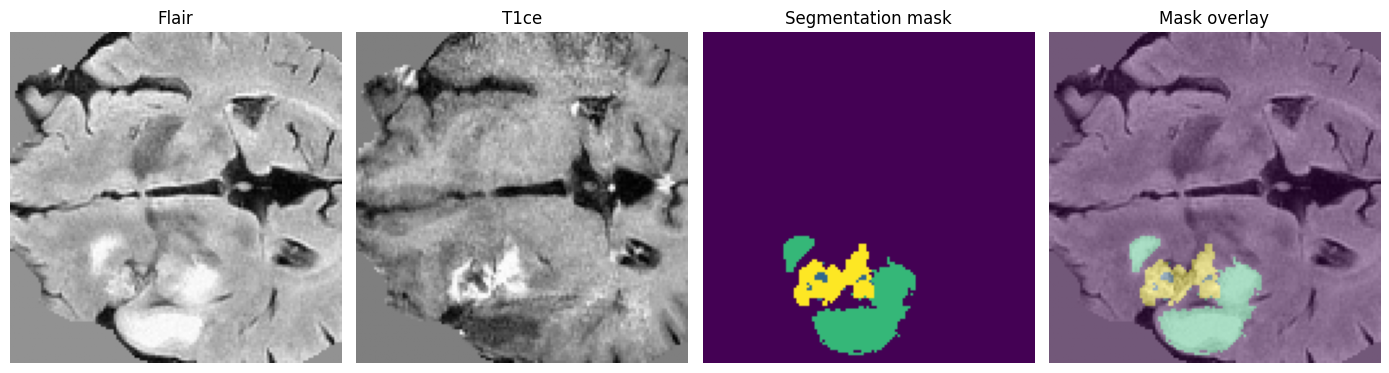

In [9]:
# ============================================================
# Cell 7: Visual check from the generator
# ============================================================

# Take one batch from the training generator
X_batch, y_batch = train_gen[0]

# Show the first image in the batch
i = 0

image = X_batch[i]
mask = np.argmax(y_batch[i], axis=-1)

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask labels:", np.unique(mask))

plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(image[:, :, 0], cmap="gray")
plt.title("Flair")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(image[:, :, 2], cmap="gray")
plt.title("T1ce")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(mask)
plt.title("Segmentation mask")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(image[:, :, 0], cmap="gray")
plt.imshow(mask, alpha=0.4)
plt.title("Mask overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Cell 8: Build the AGResU-Net model
# ============================================================

from tensorflow.keras import layers, Model

def conv_bn_prelu(x, filters, stride=1):
    # One basic convolution unit: BN -> PReLU -> 3x3 Conv
    x = layers.BatchNormalization()(x)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    x = layers.Conv2D(
        filters,
        kernel_size=3,
        strides=stride,
        padding="same",
        kernel_initializer="glorot_uniform"
    )(x)
    return x


def residual_block(x, filters, stride=1):
    # Residual block: the input is added back to the output
    shortcut = x

    x = conv_bn_prelu(x, filters, stride=stride)
    x = conv_bn_prelu(x, filters, stride=1)

    # If shape changes, adjust the shortcut with 1x1 convolution
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            kernel_initializer="glorot_uniform"
        )(shortcut)

    return layers.Add()([x, shortcut])


def attention_gate(skip, gate, filters):
    # This gate decides how much of the skip connection should pass
    skip_part = layers.Conv2D(filters, 1, padding="same")(skip)
    gate_part = layers.Conv2D(filters, 1, padding="same")(gate)

    x = layers.Add()([skip_part, gate_part])
    x = layers.Activation("relu")(x)

    alpha = layers.Conv2D(filters, 1, padding="same", activation="sigmoid")(x)

    return layers.Multiply()([skip, alpha])


def decoder_block(x, skip, filters):
    # Upsample, apply attention to the skip connection, then combine
    x = layers.UpSampling2D(size=(2, 2), interpolation="bilinear")(x)

    skip = attention_gate(skip, x, filters)

    x = layers.Concatenate()([x, skip])
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = residual_block(x, filters)

    return x


def build_agresunet(input_shape=(128, 128, 4), num_classes=4):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    e1 = residual_block(inputs, 64)          # 128x128
    e2 = residual_block(e1, 128, stride=2)   # 64x64
    e3 = residual_block(e2, 256, stride=2)   # 32x32

    # Bridge
    b = residual_block(e3, 512, stride=2)    # 16x16

    # Decoder
    d3 = decoder_block(b, e3, 256)           # 32x32
    d2 = decoder_block(d3, e2, 128)          # 64x64
    d1 = decoder_block(d2, e1, 64)           # 128x128

    # Final class probabilities
    outputs = layers.Conv2D(
        num_classes,
        kernel_size=1,
        activation="softmax",
        name="main_output"
    )(d1)

    return Model(inputs, outputs, name="AGResU_Net")


model = build_agresunet(
    input_shape=(PATCH_SIZE, PATCH_SIZE, 4),
    num_classes=NUM_CLASSES
)

print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Total parameters:", model.count_params())

# Test prediction on one batch
test_pred = model.predict(X_batch, verbose=0)

print("\nTest prediction shape:", test_pred.shape)
print("Prediction min/max:", test_pred.min(), test_pred.max())
print("Softmax sum min/max:", test_pred.sum(axis=-1).min(), test_pred.sum(axis=-1).max())

I0000 00:00:1778702305.367868     868 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9513 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model name: AGResU_Net
Input shape: (None, 128, 128, 4)
Output shape: (None, 128, 128, 4)
Total parameters: 9088472


I0000 00:00:1778702307.125781    1163 service.cc:153] XLA service 0x78eac0042650 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778702307.125813    1163 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778702307.150067    1163 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778702307.321516    1163 cuda_dnn.cc:461] Loaded cuDNN version 92101
E0000 00:00:1778702307.852092    1163 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Test prediction shape: (2, 128, 128, 4)
Prediction min/max: 0.028202824 0.78001904
Softmax sum min/max: 0.99999976 1.0000002


I0000 00:00:1778702311.166412    1163 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [11]:
# ============================================================
# Cell 9: Losses, Dice metrics, and compile the model
# ============================================================

EPS = 1e-7

# Background is common, so it gets a smaller weight.
# Enhancing tumor is harder/smaller, so it gets a higher weight.
CLASS_WEIGHTS = tf.constant([0.2, 1.0, 1.0, 2.0], dtype=tf.float32)


def generalized_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.clip_by_value(y_pred, EPS, 1.0 - EPS)

    # Sum over batch, height, and width
    axes = [0, 1, 2]

    class_sum = tf.reduce_sum(y_true, axis=axes)

    # If a class is missing in a batch, do not let it explode the loss
    weights = tf.where(
        class_sum > 0,
        1.0 / (tf.square(class_sum) + EPS),
        0.0
    )

    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    total = tf.reduce_sum(y_true + y_pred, axis=axes)

    dice = (2.0 * tf.reduce_sum(weights * intersection) + EPS) / (
        tf.reduce_sum(weights * total) + EPS
    )

    return 1.0 - dice


def weighted_cross_entropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, EPS, 1.0 - EPS)

    loss = -y_true * tf.math.log(y_pred) * CLASS_WEIGHTS

    return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))


def combined_loss(y_true, y_pred):
    return generalized_dice_loss(y_true, y_pred) + weighted_cross_entropy(y_true, y_pred)


def dice_region(y_true, y_pred, classes):
    y_true = tf.cast(y_true, tf.float32)

    true_region = tf.reduce_sum(tf.gather(y_true, classes, axis=-1), axis=-1)
    pred_region = tf.reduce_sum(tf.gather(y_pred, classes, axis=-1), axis=-1)

    intersection = tf.reduce_sum(true_region * pred_region)
    total = tf.reduce_sum(true_region) + tf.reduce_sum(pred_region)

    return (2.0 * intersection + EPS) / (total + EPS)


def dice_wt(y_true, y_pred):
    return dice_region(y_true, y_pred, [1, 2, 3])


def dice_tc(y_true, y_pred):
    return dice_region(y_true, y_pred, [1, 3])


def dice_et(y_true, y_pred):
    return dice_region(y_true, y_pred, [3])


# SGD with momentum, following the paper direction.
# The paper learning rate is high, so we use a safer value for Colab stability.
LEARNING_RATE = 0.005
MOMENTUM = 0.97

optimizer = tf.keras.optimizers.SGD(
    learning_rate=LEARNING_RATE,
    momentum=MOMENTUM
)

model.compile(
    optimizer=optimizer,
    loss=combined_loss,
    metrics=[dice_wt, dice_tc, dice_et]
)

print("Model compiled successfully.")
print("Learning rate:", LEARNING_RATE)
print("Momentum:", MOMENTUM)
print("Class weights:", CLASS_WEIGHTS.numpy())

# Quick check before training
pred_check = model(X_batch, training=False)

print("\nLoss check:", float(combined_loss(y_batch, pred_check)))
print("Dice WT check:", float(dice_wt(y_batch, pred_check)))
print("Dice TC check:", float(dice_tc(y_batch, pred_check)))
print("Dice ET check:", float(dice_et(y_batch, pred_check)))

Model compiled successfully.
Learning rate: 0.005
Momentum: 0.97
Class weights: [0.2 1.  1.  2. ]

Loss check: 1.4023312330245972
Dice WT check: 0.17062018811702728
Dice TC check: 0.09589549154043198
Dice ET check: 0.049777451902627945


In [12]:
# ============================================================
# Cell 10: Train from preprocessed .npy using generator
# ============================================================

from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, TerminateOnNaN
import time
import gc

EPOCHS = 40
BATCH_SIZE_FULL = 8
LEARNING_RATE_RUN = 0.003
MOMENTUM = 0.97
STEPS_PER_EPOCH = 1000
VAL_STEPS = 250


def one_hot_mask(mask, n_classes=NUM_CLASSES):
    out = np.zeros((*mask.shape, n_classes), dtype=np.float32)
    for c in range(n_classes):
        out[:, :, c] = (mask == c)
    return out


def tumor_center_crop_128(image_slice, mask_slice, size=128):
    h, w = mask_slice.shape

    tumor_pixels = np.argwhere(mask_slice > 0)

    if len(tumor_pixels) > 0:
        cy, cx = tumor_pixels.mean(axis=0).astype(int)
    else:
        cy, cx = h // 2, w // 2

    sh = max(0, min(cy - size // 2, h - size))
    sw = max(0, min(cx - size // 2, w - size))

    img_crop = image_slice[sh:sh + size, sw:sw + size, :]
    mask_crop = mask_slice[sh:sh + size, sw:sw + size]

    return img_crop.astype(np.float32), mask_crop.astype(np.uint8)


def tumor_aware_crop_128(image_slice, mask_slice, size=128, tumor_prob=0.85):
    h, w = mask_slice.shape
    tumor_pixels = np.argwhere(mask_slice > 0)

    if len(tumor_pixels) > 0 and random.random() < tumor_prob:
        cy, cx = tumor_pixels[random.randint(0, len(tumor_pixels) - 1)]

        sh = cy - size // 2 + random.randint(-20, 20)
        sw = cx - size // 2 + random.randint(-20, 20)

        sh = max(0, min(sh, h - size))
        sw = max(0, min(sw, w - size))
    else:
        sh = random.randint(0, max(h - size, 0))
        sw = random.randint(0, max(w - size, 0))

    img_crop = image_slice[sh:sh + size, sw:sw + size, :]
    mask_crop = mask_slice[sh:sh + size, sw:sw + size]

    return img_crop.astype(np.float32), mask_crop.astype(np.uint8)


class ProcessedBraTSGenerator(tf.keras.utils.Sequence):
    def __init__(self, processed_patient_dirs, batch_size=8, steps_per_epoch=1000,
                 augment=False, shuffle=True):
        self.patient_dirs = list(processed_patient_dirs)
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = list(range(len(self.patient_dirs)))
        self.cache = {}
        self.max_cache_size = 4
        self.on_epoch_end()

    def __len__(self):
        return self.steps_per_epoch

    def on_epoch_end(self):
        if self.shuffle:
            random.shuffle(self.indexes)

    def load_processed_patient(self, patient_dir):
        patient_dir = Path(patient_dir)
        key = str(patient_dir)

        if key in self.cache:
            return self.cache[key]

        image = np.load(patient_dir / "image_4ch.npy", mmap_mode="r")
        mask = np.load(patient_dir / "mask.npy", mmap_mode="r")
        valid_slices = np.load(patient_dir / "valid_slices.npy")

        if len(self.cache) >= self.max_cache_size:
            self.cache.pop(next(iter(self.cache)))

        self.cache[key] = (image, mask, valid_slices)
        return image, mask, valid_slices

    def augment_sample(self, X, y):
        # Structural augmentation enhancement:
        # 1) spatial flips
        # 2) 90-degree rotations
        # 3) Gaussian noise regularization only on non-background MRI voxels
        # The same spatial transform is applied to image and mask together.

        if random.random() < 0.5:
            X = np.flip(X, axis=1)
            y = np.flip(y, axis=1)

        if random.random() < 0.5:
            X = np.flip(X, axis=0)
            y = np.flip(y, axis=0)

        k = random.randint(0, 3)
        X = np.rot90(X, k, axes=(0, 1))
        y = np.rot90(y, k, axes=(0, 1))

        # Enhancement from the augmentation notebook:
        # add small Gaussian noise to the MRI channels only where signal exists.
        # This keeps the black background clean and regularizes the model.
        if random.random() < 0.5:
            noise_std = random.uniform(0.01, 0.05)
            noise = np.random.normal(0, noise_std, X.shape).astype(np.float32)
            brain_mask = (X != 0).astype(np.float32)
            X = X + noise * brain_mask

        return X.copy(), y.copy()

    def __getitem__(self, idx):
        X_batch = []
        y_batch = []

        attempts = 0

        while len(X_batch) < self.batch_size and attempts < self.batch_size * 50:
            attempts += 1

            patient_dir = self.patient_dirs[random.choice(self.indexes)]

            try:
                img_vol, mask_vol, valid_slices = self.load_processed_patient(patient_dir)

                if len(valid_slices) > 0:
                    z = int(random.choice(valid_slices))
                else:
                    z = random.randint(0, mask_vol.shape[2] - 1)

                img_slice = np.asarray(img_vol[:, :, z, :], dtype=np.float32)
                mask_slice = np.asarray(mask_vol[:, :, z], dtype=np.uint8)

                if self.augment:
                    X, y_mask = tumor_aware_crop_128(img_slice, mask_slice)
                    X, y_mask = self.augment_sample(X, y_mask)
                else:
                    X, y_mask = tumor_center_crop_128(img_slice, mask_slice)

                y = one_hot_mask(y_mask)

                X_batch.append(X)
                y_batch.append(y)

            except Exception:
                continue

        if len(X_batch) == 0:
            X_batch = np.zeros((self.batch_size, PATCH_SIZE, PATCH_SIZE, 4), dtype=np.float32)
            y_batch = np.zeros((self.batch_size, PATCH_SIZE, PATCH_SIZE, NUM_CLASSES), dtype=np.float32)
            y_batch[..., 0] = 1.0
            return X_batch, y_batch

        while len(X_batch) < self.batch_size:
            X_batch.append(X_batch[-1])
            y_batch.append(y_batch[-1])

        return np.array(X_batch, dtype=np.float32), np.array(y_batch, dtype=np.float32)


def train_one_dataset(dataset_name):
    print("\n" + "=" * 80)
    print("STARTING DATASET:", dataset_name)
    print("=" * 80)

    train_patients = DATASET_SPLITS[dataset_name]["train_patients"]
    val_patients = DATASET_SPLITS[dataset_name]["val_patients"]

    processed_train = [
        PROCESSED_DIR / dataset_name / safe_patient_name(p)
        for p in train_patients
        if (PROCESSED_DIR / dataset_name / safe_patient_name(p)).exists()
    ]

    processed_val = [
        PROCESSED_DIR / dataset_name / safe_patient_name(p)
        for p in val_patients
        if (PROCESSED_DIR / dataset_name / safe_patient_name(p)).exists()
    ]

    print("Processed train patients:", len(processed_train))
    print("Processed validation patients:", len(processed_val))

    train_gen = ProcessedBraTSGenerator(
        processed_train,
        batch_size=BATCH_SIZE_FULL,
        steps_per_epoch=STEPS_PER_EPOCH,
        augment=True,
        shuffle=True
    )

    val_gen = ProcessedBraTSGenerator(
        processed_val,
        batch_size=BATCH_SIZE_FULL,
        steps_per_epoch=VAL_STEPS,
        augment=False,
        shuffle=False
    )

    tf.keras.backend.clear_session()
    gc.collect()

    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    model_full = build_agresunet(
        input_shape=(PATCH_SIZE, PATCH_SIZE, 4),
        num_classes=NUM_CLASSES
    )

    optimizer = tf.keras.optimizers.SGD(
        learning_rate=LEARNING_RATE_RUN,
        momentum=MOMENTUM
    )

    model_full.compile(
        optimizer=optimizer,
        loss=combined_loss,
        metrics=[dice_wt, dice_tc, dice_et]
    )

    checkpoint_path = OUTPUT_DIR / f"best_agresunet_{dataset_name}_40epochs_npy_generator.keras"
    final_model_path = OUTPUT_DIR / f"final_agresunet_{dataset_name}_40epochs_npy_generator.keras"
    log_path = OUTPUT_DIR / f"training_log_{dataset_name}_40epochs_npy_generator.csv"

    callbacks = [
        ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        ),

        CSVLogger(str(log_path)),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=1
        ),

        TerminateOnNaN()
    ]

    print("Train batches per epoch:", len(train_gen))
    print("Validation batches:", len(val_gen))
    print("Best model path:", checkpoint_path)

    start_time = time.time()

    history_full = model_full.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    end_time = time.time()

    model_full.save(final_model_path)

    print("\nTraining finished for:", dataset_name)
    print("Training time in minutes:", round((end_time - start_time) / 60, 2))
    print("Best model saved to:", checkpoint_path)
    print("Final model saved to:", final_model_path)
    print("Training log saved to:", log_path)

    history_dict = history_full.history

    del model_full, train_gen, val_gen
    gc.collect()
    tf.keras.backend.clear_session()

    return history_dict

In [13]:
all_histories = {}

all_histories["brats2017"] = train_one_dataset("brats2017")


STARTING DATASET: brats2017
Processed train patients: 171
Processed validation patients: 57
Train batches per epoch: 1000
Validation batches: 250
Best model path: /home/zak/brats_project/outputs/best_agresunet_brats2017_40epochs_npy_generator.keras


/home/zak/tf-gpu/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


I0000 00:00:1778702315.582189     868 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1778702330.626436    1832 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_11', 364 bytes spill stores, 364 bytes spill loads

I0000 00:00:1778702330.772995    1832 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_7', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1778702337.205546    1161 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_11', 364 bytes spill stores, 364 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_7', 4 bytes spill stores, 4 bytes spill loads



 990/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - dice_et: 0.5782 - dice_tc: 0.4977 - dice_wt: 0.7487 - loss: 1.0851
Epoch 1: val_loss improved from None to 0.59469, saving model to /home/zak/brats_project/outputs/best_agresunet_brats2017_40epochs_npy_generator.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 172s 150ms/step - dice_et: 0.6534 - dice_tc: 0.5807 - dice_wt: 0.7773 - loss: 0.8491 - val_dice_et: 0.7230 - val_dice_tc: 0.6446 - val_dice_wt: 0.8141 - val_loss: 0.5947 - learning_rate: 0.0030
Epoch 2/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - dice_et: 0.7211 - dice_tc: 0.6810 - dice_wt: 0.8177 - loss: 0.5338
Epoch 2: val_loss improved from 0.59469 to 0.56506, saving model to /home/zak/brats_project/outputs/best_agresunet_brats2017_40epochs_npy_generator.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 137s 136ms/step - dice_et: 0.7370 - dice_tc: 0.7062 - dice_wt: 0.8225 - loss: 0.4943 - val_dice_et: 0.7445 - val_dice_tc: 0.6950 - val_dice_wt: 0.8381 - val_loss: 0.5651 - learning_rate: 0.0030
Epoch 

In [14]:
all_histories["brats2018"] = train_one_dataset("brats2018")


STARTING DATASET: brats2018
Processed train patients: 171
Processed validation patients: 57
Train batches per epoch: 1000
Validation batches: 250
Best model path: /home/zak/brats_project/outputs/best_agresunet_brats2018_40epochs_npy_generator.keras
Epoch 1/40


I0000 00:00:1778708259.408729    1163 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_11', 364 bytes spill stores, 364 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_7', 4 bytes spill stores, 4 bytes spill loads



1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - dice_et: 0.0675 - dice_tc: 0.0670 - dice_wt: 0.7386 - loss: 1.7775
Epoch 1: val_loss improved from None to 1.69122, saving model to /home/zak/brats_project/outputs/best_agresunet_brats2018_40epochs_npy_generator.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 177s 167ms/step - dice_et: 0.0170 - dice_tc: 0.0167 - dice_wt: 0.7795 - loss: 1.8085 - val_dice_et: 0.0040 - val_dice_tc: 3.2441e-11 - val_dice_wt: 0.8508 - val_loss: 1.6912 - learning_rate: 0.0030
Epoch 2/40
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - dice_et: 0.0020 - dice_tc: 2.7209e-11 - dice_wt: 0.8193 - loss: 1.7780
Epoch 2: val_loss improved from 1.69122 to 1.68248, saving model to /home/zak/brats_project/outputs/best_agresunet_brats2018_40epochs_npy_generator.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 155s 154ms/step - dice_et: 0.0040 - dice_tc: 3.0799e-11 - dice_wt: 0.8242 - loss: 1.7632 - val_dice_et: 0.0079 - val_dice_tc: 4.3229e-10 - val_dice_wt: 0.8081 - val_loss: 1.6825 - learning_rat

In [15]:
all_histories["brats2019"] = train_one_dataset("brats2019")


STARTING DATASET: brats2019
Processed train patients: 201
Processed validation patients: 67
Train batches per epoch: 1000
Validation batches: 250
Best model path: /home/zak/brats_project/outputs/best_agresunet_brats2019_40epochs_npy_generator.keras
Epoch 1/40


I0000 00:00:1778714538.324532    1163 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_11', 364 bytes spill stores, 364 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_7', 4 bytes spill stores, 4 bytes spill loads



1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - dice_et: 0.6429 - dice_tc: 0.5381 - dice_wt: 0.7669 - loss: 1.0697
Epoch 1: val_loss improved from None to 0.58083, saving model to /home/zak/brats_project/outputs/best_agresunet_brats2019_40epochs_npy_generator.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 227s 213ms/step - dice_et: 0.7090 - dice_tc: 0.6017 - dice_wt: 0.7975 - loss: 0.8395 - val_dice_et: 0.7454 - val_dice_tc: 0.6660 - val_dice_wt: 0.8010 - val_loss: 0.5808 - learning_rate: 0.0030
Epoch 2/40
 994/1000 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - dice_et: 0.7851 - dice_tc: 0.7322 - dice_wt: 0.8361 - loss: 0.4705
Epoch 2: val_loss improved from 0.58083 to 0.47314, saving model to /home/zak/brats_project/outputs/best_agresunet_brats2019_40epochs_npy_generator.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 205s 204ms/step - dice_et: 0.7841 - dice_tc: 0.7416 - dice_wt: 0.8405 - loss: 0.4501 - val_dice_et: 0.7677 - val_dice_tc: 0.7294 - val_dice_wt: 0.7814 - val_loss: 0.4731 - learning_rate: 0.0030
Epoch 

In [16]:
def load_validation_from_processed(dataset_name, max_eval_slices=1000):
    """
    Loads validation samples from preprocessed .npy patients.
    Uses tumor-centered crops.
    Limits number of samples to avoid RAM crash.
    """
    val_patients = DATASET_SPLITS[dataset_name]["val_patients"]

    processed_val = [
        PROCESSED_DIR / dataset_name / safe_patient_name(p)
        for p in val_patients
        if (PROCESSED_DIR / dataset_name / safe_patient_name(p)).exists()
    ]

    X_list = []
    y_list = []

    print("Processed validation patients:", len(processed_val))

    for patient_dir in tqdm(processed_val):
        image = np.load(patient_dir / "image_4ch.npy", mmap_mode="r")
        mask = np.load(patient_dir / "mask.npy", mmap_mode="r")
        valid_slices = np.load(patient_dir / "valid_slices.npy")

        if len(valid_slices) == 0:
            continue

        for z in valid_slices:
            z = int(z)

            img_slice = np.asarray(image[:, :, z, :], dtype=np.float32)
            mask_slice = np.asarray(mask[:, :, z], dtype=np.uint8)

            X, y_mask = tumor_center_crop_128(img_slice, mask_slice)
            y = one_hot_mask(y_mask)

            X_list.append(X)
            y_list.append(y)

            if len(X_list) >= max_eval_slices:
                break

        if len(X_list) >= max_eval_slices:
            break

    X_val = np.array(X_list, dtype=np.float32)
    y_val = np.array(y_list, dtype=np.float32)

    return X_val, y_val

In [17]:
# ============================================================
# Cell 11: Evaluate best saved model for each dataset
# Includes Dice + HD95 + plots + example prediction
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import gc
from scipy.ndimage import binary_erosion, distance_transform_edt


# -----------------------------
# Hard Dice calculation
# -----------------------------
def hard_dice(true_masks, pred_masks, labels):
    scores = []

    for i in range(true_masks.shape[0]):
        true_region = np.isin(true_masks[i], labels)
        pred_region = np.isin(pred_masks[i], labels)

        intersection = np.sum(true_region & pred_region)
        total = np.sum(true_region) + np.sum(pred_region)

        if total > 0:
            dice = (2 * intersection + 1e-7) / (total + 1e-7)
            scores.append(dice)

    if len(scores) == 0:
        return 0.0

    return np.mean(scores)


# -----------------------------
# HD95 calculation
# -----------------------------
def get_surface(mask):
    mask = mask.astype(bool)

    if mask.sum() == 0:
        return mask

    eroded = binary_erosion(mask)
    surface = mask ^ eroded

    return surface


def hd95_one_case(true_region, pred_region):
    # HD95 cannot be calculated fairly if one region is empty
    if true_region.sum() == 0 or pred_region.sum() == 0:
        return np.nan

    true_surface = get_surface(true_region)
    pred_surface = get_surface(pred_region)

    # Distances from predicted surface to true surface
    true_distance = distance_transform_edt(~true_surface)
    pred_to_true = true_distance[pred_surface]

    # Distances from true surface to predicted surface
    pred_distance = distance_transform_edt(~pred_surface)
    true_to_pred = pred_distance[true_surface]

    all_distances = np.concatenate([pred_to_true, true_to_pred])

    return np.percentile(all_distances, 95)


def mean_hd95(true_masks, pred_masks, labels):
    scores = []

    for i in range(true_masks.shape[0]):
        true_region = np.isin(true_masks[i], labels)
        pred_region = np.isin(pred_masks[i], labels)

        score = hd95_one_case(true_region, pred_region)
        scores.append(score)

    scores = np.array(scores, dtype="float32")

    mean_score = np.nanmean(scores)
    valid_cases = np.sum(~np.isnan(scores))
    total_cases = len(scores)

    return mean_score, valid_cases, total_cases


# -----------------------------
# Evaluate one dataset
# -----------------------------
def evaluate_one_dataset(dataset_name, example_index=0):
    print("\n" + "=" * 80)
    print("EVALUATING DATASET:", dataset_name)
    print("=" * 80)

    checkpoint_path = OUTPUT_DIR / f"best_agresunet_{dataset_name}_40epochs_npy_generator.keras"
    final_model_path = OUTPUT_DIR / f"final_agresunet_{dataset_name}_40epochs_npy_generator.keras"
    log_path = OUTPUT_DIR / f"training_log_{dataset_name}_40epochs_npy_generator.csv"
    print("\nCheckpoint path:")
    print(checkpoint_path)

    print("\nLog path:")
    print(log_path)

    # -----------------------------
    # Read training log
    # -----------------------------
    log_df = pd.read_csv(log_path)

    print("\nTraining log:")
    display(log_df)

    # Find best epoch using validation loss
    best_row = log_df.loc[log_df["val_loss"].idxmin()]

    print("\nBest epoch:", int(best_row["epoch"]) + 1)
    print("Best val_loss:", best_row["val_loss"])
    print("Best soft val_dice_wt:", best_row["val_dice_wt"])
    print("Best soft val_dice_tc:", best_row["val_dice_tc"])
    print("Best soft val_dice_et:", best_row["val_dice_et"])

    # -----------------------------
    # Preload validation data again
    # -----------------------------
    print("\nReloading validation data from preprocessed .npy files...")
    X_val_full, y_val_full = load_validation_from_processed(
        dataset_name,
        max_eval_slices=1000
    )

    print("\nValidation data loaded:")
    print("X_val_full:", X_val_full.shape)
    print("y_val_full:", y_val_full.shape)

    print("\nValidation labels:", np.unique(np.argmax(y_val_full, axis=-1)))

    # -----------------------------
    # Load best model
    # -----------------------------
    best_model = tf.keras.models.load_model(
        checkpoint_path,
        compile=False
    )

    print("\nLoaded best model from:")
    print(checkpoint_path)

    # -----------------------------
    # Predict on validation data
    # -----------------------------
    pred_probs = best_model.predict(
        X_val_full,
        batch_size=8,
        verbose=1
    )

    true_masks = np.argmax(y_val_full, axis=-1)
    pred_masks = np.argmax(pred_probs, axis=-1)

    print("\nTrue labels:", np.unique(true_masks))
    print("Predicted labels:", np.unique(pred_masks))

    # -----------------------------
    # Hard Dice scores
    # -----------------------------
    hard_dice_wt = hard_dice(true_masks, pred_masks, [1, 2, 3])
    hard_dice_tc = hard_dice(true_masks, pred_masks, [1, 3])
    hard_dice_et = hard_dice(true_masks, pred_masks, [3])

    # -----------------------------
    # HD95 scores
    # -----------------------------
    hd95_wt, valid_wt, total_wt = mean_hd95(true_masks, pred_masks, [1, 2, 3])
    hd95_tc, valid_tc, total_tc = mean_hd95(true_masks, pred_masks, [1, 3])
    hd95_et, valid_et, total_et = mean_hd95(true_masks, pred_masks, [3])

    hd95_table = pd.DataFrame({
        "Dataset": [dataset_name, dataset_name, dataset_name],
        "Region": ["WT", "TC", "ET"],
        "Labels used": ["1,2,3", "1,3", "3"],
        "Mean HD95": [hd95_wt, hd95_tc, hd95_et],
        "Valid cases": [valid_wt, valid_tc, valid_et],
        "Total cases": [total_wt, total_tc, total_et]
    })

    print("\nHD95 results:")
    display(hd95_table)

    # -----------------------------
    # Final results table
    # -----------------------------
    results_table = pd.DataFrame({
        "Dataset": [dataset_name],
        "Run": [f"{dataset_name} full 40-epoch preloaded run"],
        "Best epoch": [int(best_row["epoch"]) + 1],
        "Validation samples": [len(X_val_full)],
        "Best val_loss": [best_row["val_loss"]],
        "Soft Dice WT": [best_row["val_dice_wt"]],
        "Soft Dice TC": [best_row["val_dice_tc"]],
        "Soft Dice ET": [best_row["val_dice_et"]],
        "Hard Dice WT": [hard_dice_wt],
        "Hard Dice TC": [hard_dice_tc],
        "Hard Dice ET": [hard_dice_et],
        "HD95 WT": [hd95_wt],
        "HD95 TC": [hd95_tc],
        "HD95 ET": [hd95_et]
    })

    print("\nFinal validation result table:")
    display(results_table)

    # -----------------------------
    # Plot loss curve
    # -----------------------------
    plt.figure(figsize=(7, 4))
    plt.plot(log_df["epoch"] + 1, log_df["loss"], marker="o", label="Train loss")
    plt.plot(log_df["epoch"] + 1, log_df["val_loss"], marker="o", label="Val loss")
    plt.axvline(int(best_row["epoch"]) + 1, linestyle="--", label="Best epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name}: Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # Plot validation Dice
    # -----------------------------
    plt.figure(figsize=(7, 4))
    plt.plot(log_df["epoch"] + 1, log_df["val_dice_wt"], marker="o", label="WT")
    plt.plot(log_df["epoch"] + 1, log_df["val_dice_tc"], marker="o", label="TC")
    plt.plot(log_df["epoch"] + 1, log_df["val_dice_et"], marker="o", label="ET")
    plt.axvline(int(best_row["epoch"]) + 1, linestyle="--", label="Best epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Dice")
    plt.title(f"{dataset_name}: Validation Dice scores")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # Show one example prediction
    # -----------------------------
    i = example_index

    if i >= len(X_val_full):
        i = 0

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(X_val_full[i, :, :, 0], cmap="gray")
    plt.title(f"{dataset_name} Validation Flair")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_masks[i])
    plt.title("Ground truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_masks[i])
    plt.title("Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Clear RAM after this dataset
    # -----------------------------
    del X_val_full, y_val_full
    del pred_probs, true_masks, pred_masks
    del best_model
    gc.collect()
    tf.keras.backend.clear_session()

    return results_table, hd95_table


EVALUATING DATASET: brats2017

Checkpoint path:
/home/zak/brats_project/outputs/best_agresunet_brats2017_40epochs_npy_generator.keras

Log path:
/home/zak/brats_project/outputs/training_log_brats2017_40epochs_npy_generator.csv

Training log:


,epoch,dice_et,dice_tc,dice_wt,loss,val_dice_et,val_dice_tc,val_dice_wt,val_loss
0,0,0.653352,0.580682,0.777271,0.849108,0.723007,0.644613,0.814060,0.594691
1,1,0.736968,0.706163,0.822543,0.494260,0.744525,0.695030,0.838146,0.565059
2,2,0.753988,0.738479,0.840926,0.442326,0.769672,0.725452,0.865258,0.472779
3,3,0.771649,0.768554,0.856399,0.406311,0.772629,0.747785,0.854093,0.485302
4,4,0.779707,0.784360,0.863303,0.392300,0.795523,0.722755,0.847335,0.467394
5,5,0.792766,0.800624,0.868433,0.364844,0.803530,0.761350,0.847765,0.430908
6,6,0.796109,0.803512,0.867965,0.360868,0.793079,0.763770,0.872497,0.448193
7,7,0.793317,0.817496,0.870888,0.347714,0.798611,0.758010,0.870562,0.467524
8,8,0.795809,0.817631,0.873497,0.349345,0.785474,0.768401,0.869403,0.454422
9,9,0.802491,0.831236,0.879923,0.324263,0.822009,0.773931,0.885168,0.429729



Best epoch: 37
Best val_loss: 0.3984315097332001
Best soft val_dice_wt: 0.8876326084136963
Best soft val_dice_tc: 0.7912505269050598
Best soft val_dice_et: 0.8331891298294067

Reloading validation data from preprocessed .npy files...
Processed validation patients: 57


 26%|█████████████████████▊                                                             | 15/57 [00:02<00:07,  5.36it/s]



Validation data loaded:
X_val_full: (1000, 128, 128, 4)
y_val_full: (1000, 128, 128, 4)

Validation labels: [0 1 2 3]

Loaded best model from:
/home/zak/brats_project/outputs/best_agresunet_brats2017_40epochs_npy_generator.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step

True labels: [0 1 2 3]
Predicted labels: [0 1 2 3]

HD95 results:


,Dataset,Region,Labels used,Mean HD95,Valid cases,Total cases
0,brats2017,WT,"1,2,3",9.776387,979,1000
1,brats2017,TC,"1,3",6.385866,614,1000
2,brats2017,ET,3,4.573255,525,1000



Final validation result table:


,Dataset,Run,Best epoch,Validation samples,Best val_loss,Soft Dice WT,Soft Dice TC,Soft Dice ET,Hard Dice WT,Hard Dice TC,Hard Dice ET,HD95 WT,HD95 TC,HD95 ET
0,brats2017,brats2017 full 40-epoch preloaded run,37,1000,0.398432,0.887633,0.791251,0.833189,0.812509,0.670758,0.637816,9.776387,6.385866,4.573255


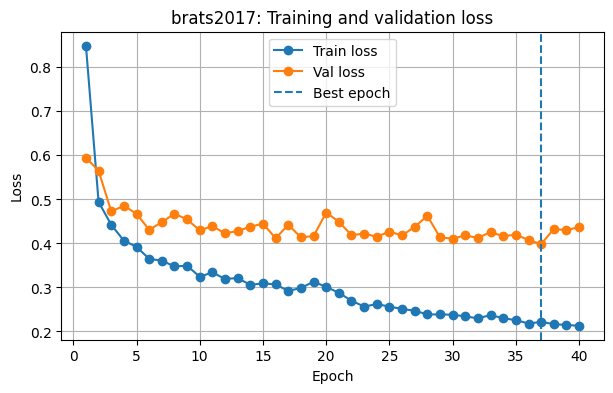

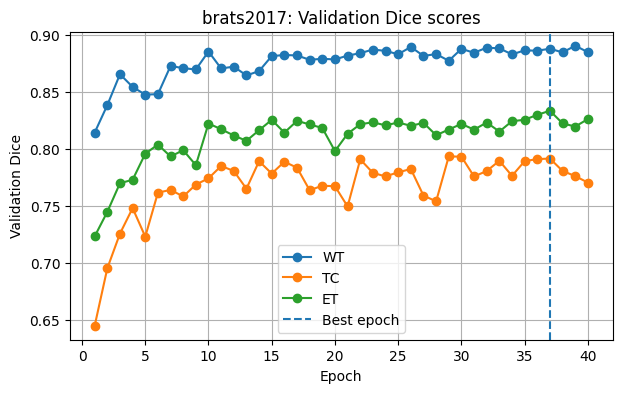

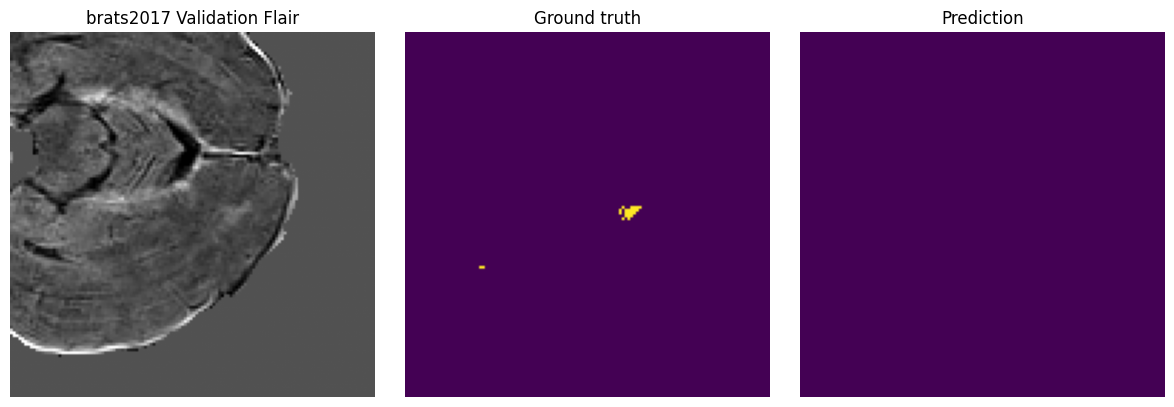


EVALUATING DATASET: brats2018

Checkpoint path:
/home/zak/brats_project/outputs/best_agresunet_brats2018_40epochs_npy_generator.keras

Log path:
/home/zak/brats_project/outputs/training_log_brats2018_40epochs_npy_generator.csv

Training log:


,epoch,dice_et,dice_tc,dice_wt,loss,val_dice_et,val_dice_tc,val_dice_wt,val_loss
0,0,0.017010,1.670561e-02,0.779459,1.808496,0.004000,3.244106e-11,0.850809,1.691221
1,1,0.004000,3.079886e-11,0.824176,1.763203,0.007907,4.322911e-10,0.808060,1.682478
2,2,0.000038,1.544110e-01,0.804915,1.767359,0.002094,5.211240e-01,0.795729,1.728550
3,3,0.169394,6.001166e-01,0.822754,1.429060,0.714233,5.900906e-01,0.839814,0.999662
4,4,0.697570,6.291121e-01,0.834505,0.997190,0.716230,6.411805e-01,0.828797,0.909912
5,5,0.736203,7.335408e-01,0.854316,0.814434,0.763496,7.335826e-01,0.844506,0.737962
6,6,0.767734,7.669382e-01,0.859182,0.702893,0.760484,7.750317e-01,0.873839,0.575206
7,7,0.771811,7.694573e-01,0.854281,0.468910,0.758067,7.656109e-01,0.855929,0.458264
8,8,0.790895,7.943734e-01,0.861970,0.389274,0.797508,7.442088e-01,0.880673,0.438566
9,9,0.793633,7.877720e-01,0.860665,0.391638,0.780559,7.583548e-01,0.819738,0.422909



Best epoch: 29
Best val_loss: 0.3402693569660187
Best soft val_dice_wt: 0.8769439458847046
Best soft val_dice_tc: 0.8021159172058105
Best soft val_dice_et: 0.8344976305961609

Reloading validation data from preprocessed .npy files...
Processed validation patients: 57


 26%|█████████████████████▊                                                             | 15/57 [00:02<00:08,  5.16it/s]



Validation data loaded:
X_val_full: (1000, 128, 128, 4)
y_val_full: (1000, 128, 128, 4)

Validation labels: [0 1 2 3]

Loaded best model from:
/home/zak/brats_project/outputs/best_agresunet_brats2018_40epochs_npy_generator.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step

True labels: [0 1 2 3]
Predicted labels: [0 1 2 3]

HD95 results:


,Dataset,Region,Labels used,Mean HD95,Valid cases,Total cases
0,brats2018,WT,"1,2,3",8.813345,976,1000
1,brats2018,TC,"1,3",6.854973,615,1000
2,brats2018,ET,3,6.288176,573,1000



Final validation result table:


,Dataset,Run,Best epoch,Validation samples,Best val_loss,Soft Dice WT,Soft Dice TC,Soft Dice ET,Hard Dice WT,Hard Dice TC,Hard Dice ET,HD95 WT,HD95 TC,HD95 ET
0,brats2018,brats2018 full 40-epoch preloaded run,29,1000,0.340269,0.876944,0.802116,0.834498,0.827601,0.68901,0.670647,8.813345,6.854973,6.288176


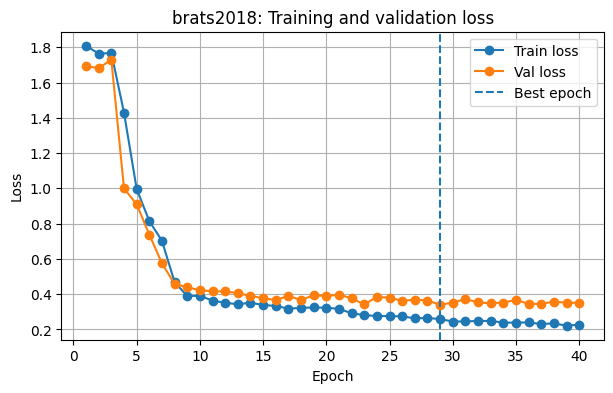

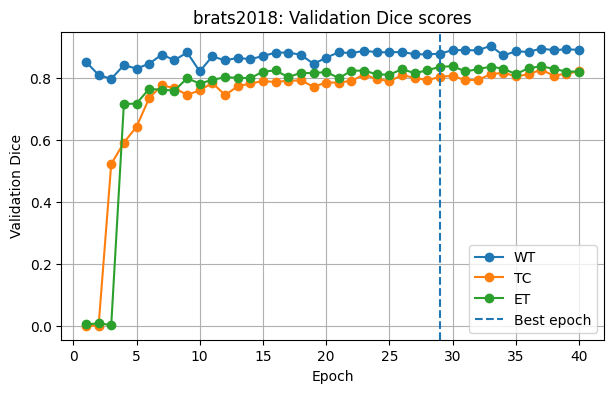

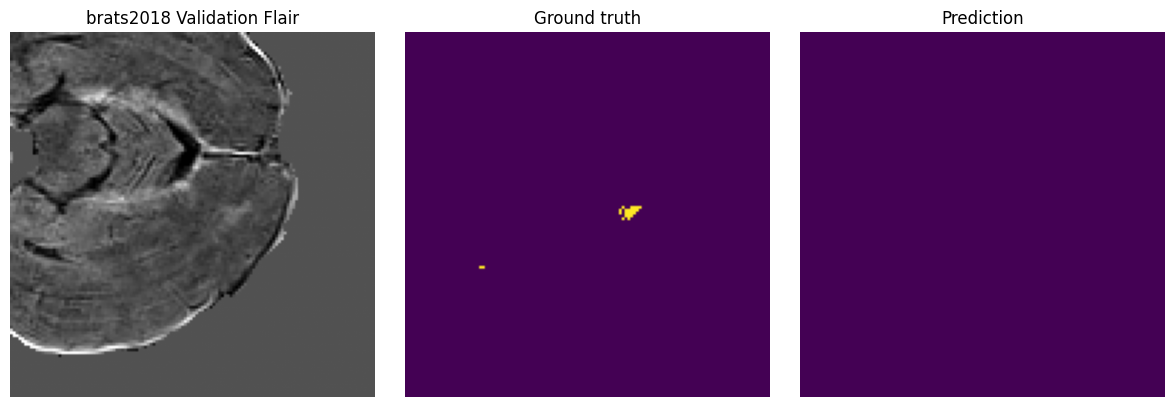


EVALUATING DATASET: brats2019

Checkpoint path:
/home/zak/brats_project/outputs/best_agresunet_brats2019_40epochs_npy_generator.keras

Log path:
/home/zak/brats_project/outputs/training_log_brats2019_40epochs_npy_generator.csv

Training log:


,epoch,dice_et,dice_tc,dice_wt,loss,val_dice_et,val_dice_tc,val_dice_wt,val_loss
0,0,0.708960,0.601744,0.797494,0.839453,0.745395,0.666002,0.801000,0.580832
1,1,0.784088,0.741564,0.840550,0.450059,0.767688,0.729432,0.781430,0.473139
2,2,0.805819,0.766301,0.858191,0.402371,0.788918,0.748985,0.852985,0.437195
3,3,0.807117,0.774533,0.869313,0.386713,0.778182,0.782556,0.870408,0.423797
4,4,0.816478,0.792915,0.870325,0.369897,0.807540,0.804939,0.871646,0.382878
5,5,0.823121,0.795168,0.873807,0.361546,0.778686,0.784624,0.858419,0.394883
6,6,0.829176,0.813144,0.881049,0.337981,0.820538,0.809606,0.876044,0.359955
7,7,0.832240,0.811168,0.883692,0.333731,0.799251,0.807264,0.883450,0.397759
8,8,0.834564,0.822787,0.885464,0.329968,0.816368,0.808982,0.885546,0.362470
9,9,0.839702,0.830606,0.888283,0.317701,0.811446,0.828933,0.853861,0.367353



Best epoch: 40
Best val_loss: 0.3244288265705108
Best soft val_dice_wt: 0.8956117630004883
Best soft val_dice_tc: 0.8563852310180664
Best soft val_dice_et: 0.8214804530143738

Reloading validation data from preprocessed .npy files...
Processed validation patients: 67


 22%|██████████████████▌                                                                | 15/67 [00:01<00:06,  8.30it/s]



Validation data loaded:
X_val_full: (1000, 128, 128, 4)
y_val_full: (1000, 128, 128, 4)

Validation labels: [0 1 2 3]

Loaded best model from:
/home/zak/brats_project/outputs/best_agresunet_brats2019_40epochs_npy_generator.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step

True labels: [0 1 2 3]
Predicted labels: [0 1 2 3]

HD95 results:


,Dataset,Region,Labels used,Mean HD95,Valid cases,Total cases
0,brats2019,WT,"1,2,3",8.367290,973,1000
1,brats2019,TC,"1,3",9.753166,669,1000
2,brats2019,ET,3,9.354920,546,1000



Final validation result table:


,Dataset,Run,Best epoch,Validation samples,Best val_loss,Soft Dice WT,Soft Dice TC,Soft Dice ET,Hard Dice WT,Hard Dice TC,Hard Dice ET,HD95 WT,HD95 TC,HD95 ET
0,brats2019,brats2019 full 40-epoch preloaded run,40,1000,0.324429,0.895612,0.856385,0.82148,0.82828,0.645153,0.640218,8.36729,9.753166,9.35492


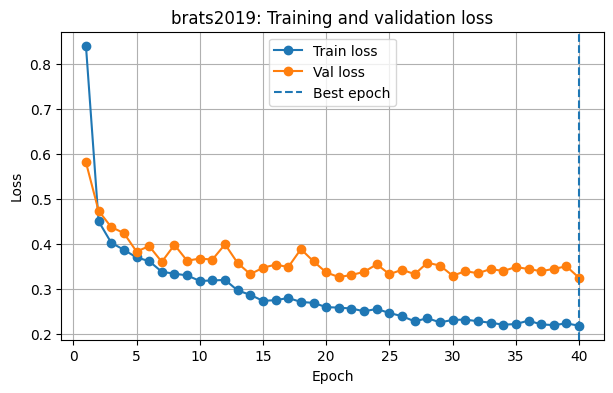

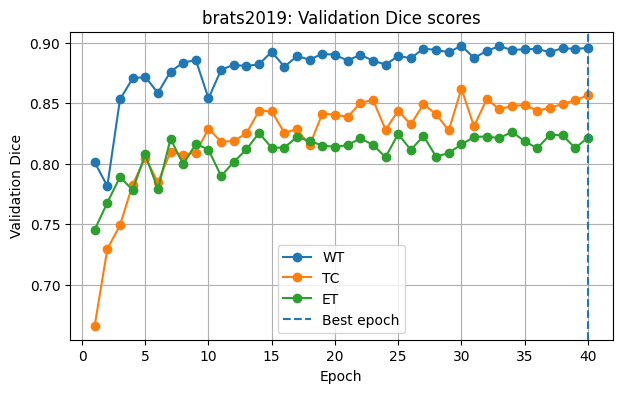

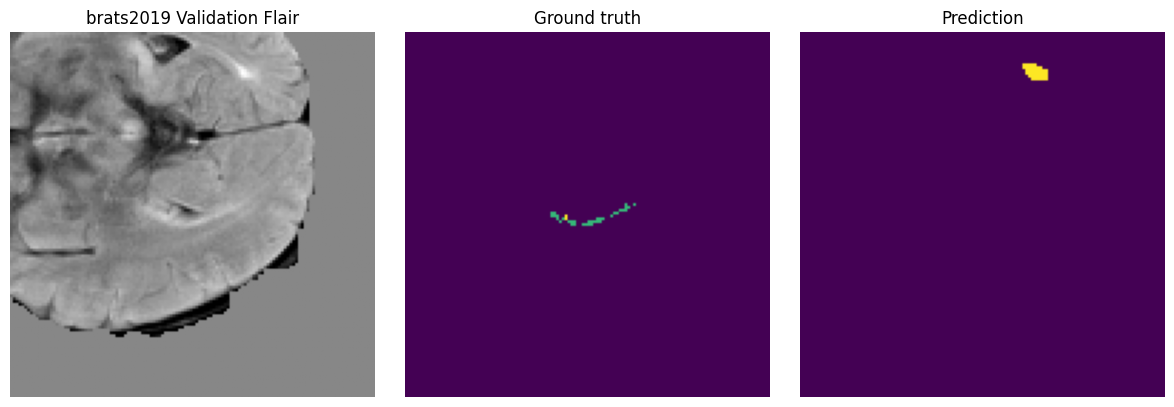


All dataset Dice + loss results:


,Dataset,Run,Best epoch,Validation samples,Best val_loss,Soft Dice WT,Soft Dice TC,Soft Dice ET,Hard Dice WT,Hard Dice TC,Hard Dice ET,HD95 WT,HD95 TC,HD95 ET
0,brats2017,brats2017 full 40-epoch preloaded run,37,1000,0.398432,0.887633,0.791251,0.833189,0.812509,0.670758,0.637816,9.776387,6.385866,4.573255
1,brats2018,brats2018 full 40-epoch preloaded run,29,1000,0.340269,0.876944,0.802116,0.834498,0.827601,0.689010,0.670647,8.813345,6.854973,6.288176
2,brats2019,brats2019 full 40-epoch preloaded run,40,1000,0.324429,0.895612,0.856385,0.821480,0.828280,0.645153,0.640218,8.367290,9.753166,9.354920



All dataset HD95 results:


,Dataset,Region,Labels used,Mean HD95,Valid cases,Total cases
0,brats2017,WT,"1,2,3",9.776387,979,1000
1,brats2017,TC,"1,3",6.385866,614,1000
2,brats2017,ET,3,4.573255,525,1000
3,brats2018,WT,"1,2,3",8.813345,976,1000
4,brats2018,TC,"1,3",6.854973,615,1000
5,brats2018,ET,3,6.288176,573,1000
6,brats2019,WT,"1,2,3",8.367290,973,1000
7,brats2019,TC,"1,3",9.753166,669,1000
8,brats2019,ET,3,9.354920,546,1000


In [18]:
# ============================================================
# Cell 12: Run evaluation for BraTS 2017, 2018, and 2019
# ============================================================

all_results = []
all_hd95_results = []

for dataset_name in ["brats2017", "brats2018", "brats2019"]:
    result_table, hd95_table = evaluate_one_dataset(dataset_name, example_index=0)

    all_results.append(result_table)
    all_hd95_results.append(hd95_table)

final_results_table = pd.concat(all_results, ignore_index=True)
final_hd95_table = pd.concat(all_hd95_results, ignore_index=True)

print("\nAll dataset Dice + loss results:")
display(final_results_table)

print("\nAll dataset HD95 results:")
display(final_hd95_table)

In [19]:
# ============================================================
# Cell 12b: 3D volumetric Dice evaluation on test patients
# Reconstructs full 3D predictions patient by patient.
# This is added as an evaluation-only enhancement.
# It does not change loading, preprocessing, augmentation, training,
# parameters, losses, or the saved models.
# ============================================================

# Paper AGResU-Net Dice values from Table 8
# BraTS 2017 validation: WT/TC/ET = 0.880, 0.781, 0.749
# BraTS 2018 validation: WT/TC/ET = 0.872, 0.808, 0.772
# BraTS 2019 validation: WT/TC/ET = 0.870, 0.777, 0.709
PAPER_DICE_3D = {
    "brats2017": {"WT": 0.880, "TC": 0.781, "ET": 0.749},
    "brats2018": {"WT": 0.872, "TC": 0.808, "ET": 0.772},
    "brats2019": {"WT": 0.870, "TC": 0.777, "ET": 0.709},
}


def center_crop_coords(h, w, size=128):
    """Return the fixed center-crop coordinates used for 3D reconstruction."""
    start_h = (h - size) // 2
    start_w = (w - size) // 2
    return start_h, start_w


def volumetric_dice_score(true_vol, pred_vol, labels):
    """Compute Dice on a whole 3D volume for one BraTS region."""
    true_region = np.isin(true_vol, labels)
    pred_region = np.isin(pred_vol, labels)

    intersection = np.sum(true_region & pred_region)
    total = np.sum(true_region) + np.sum(pred_region)

    if total == 0:
        return np.nan

    return (2.0 * intersection + 1e-7) / (total + 1e-7)


def evaluate_processed_patient_3d(processed_patient_dir, model, patch_size=128):
    """
    Run slice-by-slice inference on one preprocessed 3D patient.

    The model predicts a 128x128 patch for every axial slice.
    The predicted patch is inserted back into a full-size 3D prediction volume,
    then Dice is calculated over the full 3D patient volume.
    """
    processed_patient_dir = Path(processed_patient_dir)

    image_vol = np.load(processed_patient_dir / "image_4ch.npy", mmap_mode="r")
    mask_vol = np.load(processed_patient_dir / "mask.npy", mmap_mode="r")

    h, w, depth, channels = image_vol.shape
    start_h, start_w = center_crop_coords(h, w, patch_size)

    pred_vol = np.zeros(mask_vol.shape, dtype=np.uint8)

    for z in range(depth):
        image_slice = np.asarray(image_vol[:, :, z, :], dtype=np.float32)

        x_patch = image_slice[
            start_h:start_h + patch_size,
            start_w:start_w + patch_size,
            :
        ]

        x_patch = x_patch[np.newaxis, ...]

        pred_probs = model.predict(x_patch, verbose=0)
        pred_patch = np.argmax(pred_probs[0], axis=-1).astype(np.uint8)

        pred_vol[
            start_h:start_h + patch_size,
            start_w:start_w + patch_size,
            z
        ] = pred_patch

    # Internal labels are 0,1,2,3 because label 4 was remapped to 3.
    # Use internal labels for Dice regions:
    # WT = labels 1,2,3 | TC = labels 1,3 | ET = label 3
    return {
        "Dice WT": volumetric_dice_score(mask_vol, pred_vol, [1, 2, 3]),
        "Dice TC": volumetric_dice_score(mask_vol, pred_vol, [1, 3]),
        "Dice ET": volumetric_dice_score(mask_vol, pred_vol, [3]),
    }


def evaluate_one_dataset_3d(dataset_name, max_patients=10):
    """Evaluate 3D volumetric Dice for one dataset using its saved best model."""
    print("\n" + "=" * 80)
    print("3D VOLUMETRIC DICE EVALUATION:", dataset_name)
    print("=" * 80)

    checkpoint_path = OUTPUT_DIR / f"best_agresunet_{dataset_name}_40epochs_npy_generator.keras"

    print("\nLoading best model from:")
    print(checkpoint_path)

    if not checkpoint_path.exists():
        print("Checkpoint not found. Skipping:", checkpoint_path)
        return None, None

    test_patients = DATASET_SPLITS[dataset_name]["test_patients"]

    processed_test = [
        PROCESSED_DIR / dataset_name / safe_patient_name(p)
        for p in test_patients
        if (PROCESSED_DIR / dataset_name / safe_patient_name(p)).exists()
    ]

    if len(processed_test) == 0:
        print("No processed test patients found. Skipping:", dataset_name)
        return None, None

    processed_test = processed_test[:min(max_patients, len(processed_test))]

    print("Processed test patients evaluated:", len(processed_test))

    best_model = tf.keras.models.load_model(
        checkpoint_path,
        compile=False
    )

    patient_rows = []

    for patient_dir in tqdm(processed_test):
        scores = evaluate_processed_patient_3d(
            patient_dir,
            best_model,
            patch_size=PATCH_SIZE
        )

        patient_rows.append({
            "Dataset": dataset_name,
            "Patient": patient_dir.name,
            "Dice WT": scores["Dice WT"],
            "Dice TC": scores["Dice TC"],
            "Dice ET": scores["Dice ET"]
        })

    patient_3d_df = pd.DataFrame(patient_rows)

    paper_values = PAPER_DICE_3D[dataset_name]

    summary_3d_df = pd.DataFrame({
        "Dataset": [dataset_name, dataset_name, dataset_name],
        "Region": ["WT", "TC", "ET"],
        "Labels used internally": ["1,2,3", "1,3", "3"],
        "Mean 3D Dice": [
            float(np.nanmean(patient_3d_df["Dice WT"])),
            float(np.nanmean(patient_3d_df["Dice TC"])),
            float(np.nanmean(patient_3d_df["Dice ET"])),
        ],
        "Paper AGResU-Net Dice": [
            paper_values["WT"],
            paper_values["TC"],
            paper_values["ET"],
        ],
        "Patients evaluated": [
            int(patient_3d_df["Dice WT"].notna().sum()),
            int(patient_3d_df["Dice TC"].notna().sum()),
            int(patient_3d_df["Dice ET"].notna().sum()),
        ]
    })

    summary_3d_df["Difference from paper"] = (
        summary_3d_df["Mean 3D Dice"] - summary_3d_df["Paper AGResU-Net Dice"]
    )

    print("\nPer-patient 3D Dice:")
    display(patient_3d_df)

    print("\n3D volumetric Dice summary:")
    display(summary_3d_df)

    patient_path = OUTPUT_DIR / f"volumetric_dice_3d_patients_{dataset_name}.csv"
    summary_path = OUTPUT_DIR / f"volumetric_dice_3d_summary_{dataset_name}.csv"

    patient_3d_df.to_csv(patient_path, index=False)
    summary_3d_df.to_csv(summary_path, index=False)

    print("\nSaved 3D patient results to:", patient_path)
    print("Saved 3D summary to:", summary_path)

    del best_model
    gc.collect()
    tf.keras.backend.clear_session()

    return patient_3d_df, summary_3d_df


# Run 3D volumetric Dice for all datasets
all_3d_patient_results = []
all_3d_summary_results = []

N_PATIENTS_3D = 10

for dataset_name in ["brats2017", "brats2018", "brats2019"]:
    patient_3d_df, summary_3d_df = evaluate_one_dataset_3d(
        dataset_name,
        max_patients=N_PATIENTS_3D
    )

    if patient_3d_df is not None:
        all_3d_patient_results.append(patient_3d_df)
        all_3d_summary_results.append(summary_3d_df)

if len(all_3d_summary_results) > 0:
    final_3d_patient_results = pd.concat(all_3d_patient_results, ignore_index=True)
    final_3d_summary_table = pd.concat(all_3d_summary_results, ignore_index=True)

    print("\nCombined 3D volumetric Dice patient results:")
    display(final_3d_patient_results)

    print("\nCombined 3D volumetric Dice summary:")
    display(final_3d_summary_table)

    combined_patient_path = OUTPUT_DIR / "volumetric_dice_3d_patients_all_datasets.csv"
    combined_summary_path = OUTPUT_DIR / "volumetric_dice_3d_summary_all_datasets.csv"

    final_3d_patient_results.to_csv(combined_patient_path, index=False)
    final_3d_summary_table.to_csv(combined_summary_path, index=False)

    print("\nSaved combined 3D patient results to:", combined_patient_path)
    print("Saved combined 3D summary to:", combined_summary_path)
else:
    print("No 3D volumetric results were produced.")



3D VOLUMETRIC DICE EVALUATION: brats2017

Loading best model from:
/home/zak/brats_project/outputs/best_agresunet_brats2017_40epochs_npy_generator.keras
Processed test patients evaluated: 10


100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [01:47<00:00, 10.78s/it]


Per-patient 3D Dice:


,Dataset,Patient,Dice WT,Dice TC,Dice ET
0,brats2017,Brats17_2013_5_1,0.817348,0.850483,8.760352e-01
1,brats2017,Brats17_CBICA_ATB_1,0.835515,0.886556,8.321429e-01
2,brats2017,Brats17_CBICA_ALN_1,0.845573,0.901128,7.374087e-01
3,brats2017,Brats17_CBICA_ANP_1,0.770707,0.799333,7.410377e-01
4,brats2017,Brats17_CBICA_APZ_1,0.745419,0.918246,8.313576e-01
5,brats2017,Brats17_TCIA_491_1,0.804932,0.927093,9.257725e-01
6,brats2017,Brats17_2013_3_1,0.878924,0.857433,8.451459e-01
7,brats2017,Brats17_TCIA_387_1,0.882161,0.640191,5.802048e-01
8,brats2017,Brats17_TCIA_623_1,0.914500,0.845597,1.858391e-11
9,brats2017,Brats17_CBICA_ALU_1,0.816993,0.877630,8.401180e-01



3D volumetric Dice summary:


...


Saved 3D patient results to: /home/zak/brats_project/outputs/volumetric_dice_3d_patients_brats2019.csv
Saved 3D summary to: /home/zak/brats_project/outputs/volumetric_dice_3d_summary_brats2019.csv

Combined 3D volumetric Dice patient results:


,Dataset,Patient,Dice WT,Dice TC,Dice ET
0,brats2017,Brats17_2013_5_1,0.817348,0.850483,8.760352e-01
1,brats2017,Brats17_CBICA_ATB_1,0.835515,0.886556,8.321429e-01
2,brats2017,Brats17_CBICA_ALN_1,0.845573,0.901128,7.374087e-01
3,brats2017,Brats17_CBICA_ANP_1,0.770707,0.799333,7.410377e-01
4,brats2017,Brats17_CBICA_APZ_1,0.745419,0.918246,8.313576e-01
5,brats2017,Brats17_TCIA_491_1,0.804932,0.927093,9.257725e-01
6,brats2017,Brats17_2013_3_1,0.878924,0.857433,8.451459e-01
7,brats2017,Brats17_TCIA_387_1,0.882161,0.640191,5.802048e-01
8,brats2017,Brats17_TCIA_623_1,0.914500,0.845597,1.858391e-11
9,brats2017,Brats17_CBICA_ALU_1,0.816993,0.877630,8.401180e-01



Combined 3D volumetric Dice summary:


,Dataset,Region,Labels used internally,Mean 3D Dice,Paper AGResU-Net Dice,Patients evaluated,Difference from paper
0,brats2017,WT,"1,2,3",0.831207,0.880,10,-0.048793
1,brats2017,TC,"1,3",0.850369,0.781,10,0.069369
2,brats2017,ET,3,0.720922,0.749,10,-0.028078
3,brats2018,WT,"1,2,3",0.839515,0.872,10,-0.032485
4,brats2018,TC,"1,3",0.879540,0.808,10,0.071540
5,brats2018,ET,3,0.700303,0.772,10,-0.071697
6,brats2019,WT,"1,2,3",0.798624,0.870,10,-0.071376
7,brats2019,TC,"1,3",0.697272,0.777,10,-0.079728
8,brats2019,ET,3,0.698073,0.709,10,-0.010927



Saved combined 3D patient results to: /home/zak/brats_project/outputs/volumetric_dice_3d_patients_all_datasets.csv
Saved combined 3D summary to: /home/zak/brats_project/outputs/volumetric_dice_3d_summary_all_datasets.csv


In [20]:
# ============================================================
# Cell 13: Final result table for all datasets
# and comparison with the paper
# ============================================================

# Paper AGResU-Net values from the paper
# BraTS 2017 validation:
# Dice WT/TC/ET = 0.880, 0.781, 0.749
# HD95 WT/TC/ET = 6.87, 9.31, 3.74
#
# BraTS 2018 validation:
# Dice WT/TC/ET = 0.872, 0.808, 0.772
# HD95 WT/TC/ET = 5.62, 8.36, 3.57
#
# BraTS 2019 validation:
# Dice WT/TC/ET = 0.870, 0.777, 0.709
# HD95 is not directly reported in Table 8

paper_values = {
    "brats2017": {
        "Dice WT": 0.880,
        "Dice TC": 0.781,
        "Dice ET": 0.749,
        "HD95 WT": 6.87,
        "HD95 TC": 9.31,
        "HD95 ET": 3.74
    },
    "brats2018": {
        "Dice WT": 0.872,
        "Dice TC": 0.808,
        "Dice ET": 0.772,
        "HD95 WT": 5.62,
        "HD95 TC": 8.36,
        "HD95 ET": 3.57
    },
    "brats2019": {
        "Dice WT": 0.870,
        "Dice TC": 0.777,
        "Dice ET": 0.709,
        "HD95 WT": "Not reported in Table 8",
        "HD95 TC": "Not reported in Table 8",
        "HD95 ET": "Not reported in Table 8"
    }
}


all_comparisons = []
all_summaries = []

for dataset_name in ["brats2017", "brats2018", "brats2019"]:

    print("\n" + "=" * 80)
    print("FINAL SUMMARY FOR:", dataset_name)
    print("=" * 80)

    # Get this dataset result from Cell 12
    dataset_result = final_results_table[
        final_results_table["Dataset"] == dataset_name
    ].iloc[0]

    dataset_hd95 = final_hd95_table[
        final_hd95_table["Dataset"] == dataset_name
    ]

    # Our hard Dice values
    our_hard_wt = float(dataset_result["Hard Dice WT"])
    our_hard_tc = float(dataset_result["Hard Dice TC"])
    our_hard_et = float(dataset_result["Hard Dice ET"])

    # Our soft Dice values from training log best epoch
    our_soft_wt = float(dataset_result["Soft Dice WT"])
    our_soft_tc = float(dataset_result["Soft Dice TC"])
    our_soft_et = float(dataset_result["Soft Dice ET"])

    # Our HD95 values
    our_hd95_wt = float(dataset_hd95.loc[dataset_hd95["Region"] == "WT", "Mean HD95"].iloc[0])
    our_hd95_tc = float(dataset_hd95.loc[dataset_hd95["Region"] == "TC", "Mean HD95"].iloc[0])
    our_hd95_et = float(dataset_hd95.loc[dataset_hd95["Region"] == "ET", "Mean HD95"].iloc[0])

    # Paper values for this dataset
    paper_wt = paper_values[dataset_name]["Dice WT"]
    paper_tc = paper_values[dataset_name]["Dice TC"]
    paper_et = paper_values[dataset_name]["Dice ET"]

    paper_hd95_wt = paper_values[dataset_name]["HD95 WT"]
    paper_hd95_tc = paper_values[dataset_name]["HD95 TC"]
    paper_hd95_et = paper_values[dataset_name]["HD95 ET"]

    final_comparison = pd.DataFrame({
        "Dataset": [
            dataset_name,
            dataset_name,
            dataset_name,
            dataset_name,
            dataset_name,
            dataset_name
        ],
        "Metric": [
            "Dice WT",
            "Dice TC",
            "Dice ET",
            "HD95 WT",
            "HD95 TC",
            "HD95 ET"
        ],
        "Our result": [
            our_hard_wt,
            our_hard_tc,
            our_hard_et,
            our_hd95_wt,
            our_hd95_tc,
            our_hd95_et
        ],
        "Our soft Dice": [
            our_soft_wt,
            our_soft_tc,
            our_soft_et,
            "",
            "",
            ""
        ],
        "Paper AGResU-Net result": [
            paper_wt,
            paper_tc,
            paper_et,
            paper_hd95_wt,
            paper_hd95_tc,
            paper_hd95_et
        ],
        "Difference from paper": [
            our_hard_wt - paper_wt,
            our_hard_tc - paper_tc,
            our_hard_et - paper_et,
            our_hd95_wt - paper_hd95_wt if isinstance(paper_hd95_wt, (int, float)) else "Not calculated",
            our_hd95_tc - paper_hd95_tc if isinstance(paper_hd95_tc, (int, float)) else "Not calculated",
            our_hd95_et - paper_hd95_et if isinstance(paper_hd95_et, (int, float)) else "Not calculated"
        ],
        "Notes": [
            "Hard Dice from our validation slices",
            "Hard Dice from our validation slices",
            "Hard Dice from our validation slices",
            "Our HD95 is 2D validation-slice HD95",
            "Our HD95 is 2D validation-slice HD95",
            "Our HD95 is 2D validation-slice HD95"
        ]
    })

    checkpoint_path = OUTPUT_DIR / f"best_agresunet_{dataset_name}_allpatients_40epochs_preloaded.keras"
    final_model_path = OUTPUT_DIR / f"final_agresunet_{dataset_name}_allpatients_40epochs_preloaded.keras"
    log_path = OUTPUT_DIR / f"training_log_{dataset_name}_allpatients_40epochs_preloaded.csv"

    train_index = DATASET_INDEXES[dataset_name]["train_index"]
    val_index = DATASET_INDEXES[dataset_name]["val_index"]

    train_patients = DATASET_SPLITS[dataset_name]["train_patients"]
    val_patients = DATASET_SPLITS[dataset_name]["val_patients"]
    test_patients = DATASET_SPLITS[dataset_name]["test_patients"]
    all_patients = DATASET_SPLITS[dataset_name]["all_patients"]

    run_summary = pd.DataFrame({
        "Dataset": [dataset_name] * 17,
        "Item": [
            "Dataset",
            "Model",
            "Input shape",
            "Patients found",
            "Training patients",
            "Validation patients",
            "Test patients",
            "Training tumor slices",
            "Validation tumor slices",
            "Training samples used after augmentation",
            "Validation samples used",
            "Epochs trained",
            "Best epoch",
            "Best val_loss",
            "Optimizer",
            "Best model path",
            "Training log path"
        ],
        "Value": [
            dataset_name,
            "AGResU-Net",
            f"{PATCH_SIZE} x {PATCH_SIZE} x 4",
            len(all_patients),
            len(train_patients),
            len(val_patients),
            len(test_patients),
            len(train_index),
            len(val_index),
            len(train_index) * 2,
            len(val_index),
            EPOCHS,
            int(dataset_result["Best epoch"]),
            float(dataset_result["Best val_loss"]),
            f"SGD, learning_rate={LEARNING_RATE_RUN}, momentum={MOMENTUM}",
            str(checkpoint_path),
            str(log_path)
        ]
    })

    print("\nRun summary:")
    display(run_summary)

    print("\nFinal comparison table:")
    display(final_comparison)

    all_summaries.append(run_summary)
    all_comparisons.append(final_comparison)


# Combine all datasets into final tables
final_run_summary_all = pd.concat(all_summaries, ignore_index=True)
final_comparison_all = pd.concat(all_comparisons, ignore_index=True)

print("\n" + "=" * 80)
print("ALL DATASETS FINAL RUN SUMMARY")
print("=" * 80)
display(final_run_summary_all)

print("\n" + "=" * 80)
print("ALL DATASETS FINAL COMPARISON")
print("=" * 80)
display(final_comparison_all)


# Save final tables
summary_path = OUTPUT_DIR / "run_summary_all_datasets.csv"
comparison_path = OUTPUT_DIR / "comparison_with_paper_all_datasets.csv"
hd95_path = OUTPUT_DIR / "hd95_results_all_datasets.csv"
results_path = OUTPUT_DIR / "dice_results_all_datasets.csv"

final_run_summary_all.to_csv(summary_path, index=False)
final_comparison_all.to_csv(comparison_path, index=False)
final_hd95_table.to_csv(hd95_path, index=False)
final_results_table.to_csv(results_path, index=False)

print("\nSaved files:")
print(summary_path)
print(comparison_path)
print(hd95_path)
print(results_path)


FINAL SUMMARY FOR: brats2017

Run summary:


,Dataset,Item,Value
0,brats2017,Dataset,brats2017
1,brats2017,Model,AGResU-Net
2,brats2017,Input shape,128 x 128 x 4
3,brats2017,Patients found,285
4,brats2017,Training patients,171
5,brats2017,Validation patients,57
6,brats2017,Test patients,57
7,brats2017,Training tumor slices,11085
8,brats2017,Validation tumor slices,3621
9,brats2017,Training samples used after augmentation,22170



Final comparison table:


,Dataset,Metric,Our result,Our soft Dice,Paper AGResU-Net result,Difference from paper,Notes
0,brats2017,Dice WT,0.812509,0.887633,0.880,-0.067491,Hard Dice from our validation slices
1,brats2017,Dice TC,0.670758,0.791251,0.781,-0.110242,Hard Dice from our validation slices
2,brats2017,Dice ET,0.637816,0.833189,0.749,-0.111184,Hard Dice from our validation slices
3,brats2017,HD95 WT,9.776387,,6.870,2.906387,Our HD95 is 2D validation-slice HD95
4,brats2017,HD95 TC,6.385866,,9.310,-2.924134,Our HD95 is 2D validation-slice HD95
5,brats2017,HD95 ET,4.573255,,3.740,0.833255,Our HD95 is 2D validation-slice HD95



FINAL SUMMARY FOR: brats2018

Run summary:


...


ALL DATASETS FINAL RUN SUMMARY


,Dataset,Item,Value
0,brats2017,Dataset,brats2017
1,brats2017,Model,AGResU-Net
2,brats2017,Input shape,128 x 128 x 4
3,brats2017,Patients found,285
4,brats2017,Training patients,171
5,brats2017,Validation patients,57
6,brats2017,Test patients,57
7,brats2017,Training tumor slices,11085
8,brats2017,Validation tumor slices,3621
9,brats2017,Training samples used after augmentation,22170



ALL DATASETS FINAL COMPARISON


,Dataset,Metric,Our result,Our soft Dice,Paper AGResU-Net result,Difference from paper,Notes
0,brats2017,Dice WT,0.812509,0.887633,0.88,-0.067491,Hard Dice from our validation slices
1,brats2017,Dice TC,0.670758,0.791251,0.781,-0.110242,Hard Dice from our validation slices
2,brats2017,Dice ET,0.637816,0.833189,0.749,-0.111184,Hard Dice from our validation slices
3,brats2017,HD95 WT,9.776387,,6.87,2.906387,Our HD95 is 2D validation-slice HD95
4,brats2017,HD95 TC,6.385866,,9.31,-2.924134,Our HD95 is 2D validation-slice HD95
5,brats2017,HD95 ET,4.573255,,3.74,0.833255,Our HD95 is 2D validation-slice HD95
6,brats2018,Dice WT,0.827601,0.876944,0.872,-0.044399,Hard Dice from our validation slices
7,brats2018,Dice TC,0.689010,0.802116,0.808,-0.11899,Hard Dice from our validation slices
8,brats2018,Dice ET,0.670647,0.834498,0.772,-0.101353,Hard Dice from our validation slices
9,brats2018,HD95 WT,8.813345,,5.62,3.193345,Our HD95 is 2D validation-slice HD95



Saved files:
/home/zak/brats_project/outputs/run_summary_all_datasets.csv
/home/zak/brats_project/outputs/comparison_with_paper_all_datasets.csv
/home/zak/brats_project/outputs/hd95_results_all_datasets.csv
/home/zak/brats_project/outputs/dice_results_all_datasets.csv


In [21]:
# ============================================================
# Cell 14: Final summary and plots for all 3 datasets
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Make sure these were created from Cell 12 / Cell 13:
# final_results_table
# final_hd95_table
# final_comparison_all

print("Final Dice results from evaluation:")
display(final_results_table)

print("\nFinal HD95 results:")
display(final_hd95_table)


# ------------------------------------------------------------
# 1) Build one clean summary table
# ------------------------------------------------------------

summary_rows = []

for dataset_name in ["brats2017", "brats2018", "brats2019"]:

    dataset_result = final_results_table[
        final_results_table["Dataset"] == dataset_name
    ].iloc[0]

    dataset_hd95 = final_hd95_table[
        final_hd95_table["Dataset"] == dataset_name
    ]

    hd95_wt = dataset_hd95.loc[dataset_hd95["Region"] == "WT", "Mean HD95"].iloc[0]
    hd95_tc = dataset_hd95.loc[dataset_hd95["Region"] == "TC", "Mean HD95"].iloc[0]
    hd95_et = dataset_hd95.loc[dataset_hd95["Region"] == "ET", "Mean HD95"].iloc[0]

    summary_rows.append({
        "Dataset": dataset_name,
        "Best epoch": dataset_result["Best epoch"],
        "Best val_loss": dataset_result["Best val_loss"],

        "Soft Dice WT": dataset_result["Soft Dice WT"],
        "Soft Dice TC": dataset_result["Soft Dice TC"],
        "Soft Dice ET": dataset_result["Soft Dice ET"],

        "Hard Dice WT": dataset_result["Hard Dice WT"],
        "Hard Dice TC": dataset_result["Hard Dice TC"],
        "Hard Dice ET": dataset_result["Hard Dice ET"],

        "HD95 WT": hd95_wt,
        "HD95 TC": hd95_tc,
        "HD95 ET": hd95_et
    })

final_summary_all_datasets = pd.DataFrame(summary_rows)

print("\nFinal summary for all 3 datasets:")
display(final_summary_all_datasets)


# Save summary table
summary_all_path = OUTPUT_DIR / "final_summary_all_3_datasets.csv"
final_summary_all_datasets.to_csv(summary_all_path, index=False)

print("\nSaved final summary to:")
print(summary_all_path)

Final Dice results from evaluation:


,Dataset,Run,Best epoch,Validation samples,Best val_loss,Soft Dice WT,Soft Dice TC,Soft Dice ET,Hard Dice WT,Hard Dice TC,Hard Dice ET,HD95 WT,HD95 TC,HD95 ET
0,brats2017,brats2017 full 40-epoch preloaded run,37,1000,0.398432,0.887633,0.791251,0.833189,0.812509,0.670758,0.637816,9.776387,6.385866,4.573255
1,brats2018,brats2018 full 40-epoch preloaded run,29,1000,0.340269,0.876944,0.802116,0.834498,0.827601,0.689010,0.670647,8.813345,6.854973,6.288176
2,brats2019,brats2019 full 40-epoch preloaded run,40,1000,0.324429,0.895612,0.856385,0.821480,0.828280,0.645153,0.640218,8.367290,9.753166,9.354920



Final HD95 results:


,Dataset,Region,Labels used,Mean HD95,Valid cases,Total cases
0,brats2017,WT,"1,2,3",9.776387,979,1000
1,brats2017,TC,"1,3",6.385866,614,1000
2,brats2017,ET,3,4.573255,525,1000
3,brats2018,WT,"1,2,3",8.813345,976,1000
4,brats2018,TC,"1,3",6.854973,615,1000
5,brats2018,ET,3,6.288176,573,1000
6,brats2019,WT,"1,2,3",8.367290,973,1000
7,brats2019,TC,"1,3",9.753166,669,1000
8,brats2019,ET,3,9.354920,546,1000



Final summary for all 3 datasets:


,Dataset,Best epoch,Best val_loss,Soft Dice WT,Soft Dice TC,Soft Dice ET,Hard Dice WT,Hard Dice TC,Hard Dice ET,HD95 WT,HD95 TC,HD95 ET
0,brats2017,37,0.398432,0.887633,0.791251,0.833189,0.812509,0.670758,0.637816,9.776387,6.385866,4.573255
1,brats2018,29,0.340269,0.876944,0.802116,0.834498,0.827601,0.689010,0.670647,8.813345,6.854973,6.288176
2,brats2019,40,0.324429,0.895612,0.856385,0.821480,0.828280,0.645153,0.640218,8.367290,9.753166,9.354920



Saved final summary to:
/home/zak/brats_project/outputs/final_summary_all_3_datasets.csv


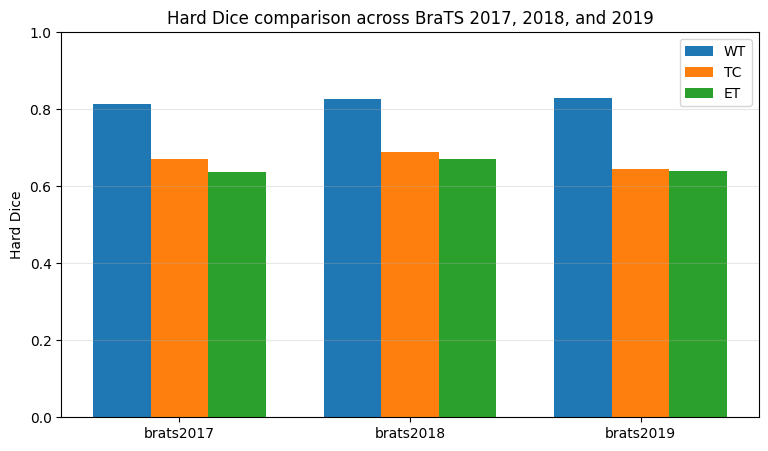

Saved Dice plot to:
/home/zak/brats_project/outputs/hard_dice_comparison_all_datasets.png


In [22]:
# ============================================================
# Plot 1: Hard Dice comparison for WT, TC, ET
# ============================================================

datasets = final_summary_all_datasets["Dataset"]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - width, final_summary_all_datasets["Hard Dice WT"], width, label="WT")
plt.bar(x, final_summary_all_datasets["Hard Dice TC"], width, label="TC")
plt.bar(x + width, final_summary_all_datasets["Hard Dice ET"], width, label="ET")

plt.xticks(x, datasets)
plt.ylabel("Hard Dice")
plt.title("Hard Dice comparison across BraTS 2017, 2018, and 2019")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

dice_plot_path = OUTPUT_DIR / "hard_dice_comparison_all_datasets.png"
plt.savefig(dice_plot_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved Dice plot to:")
print(dice_plot_path)

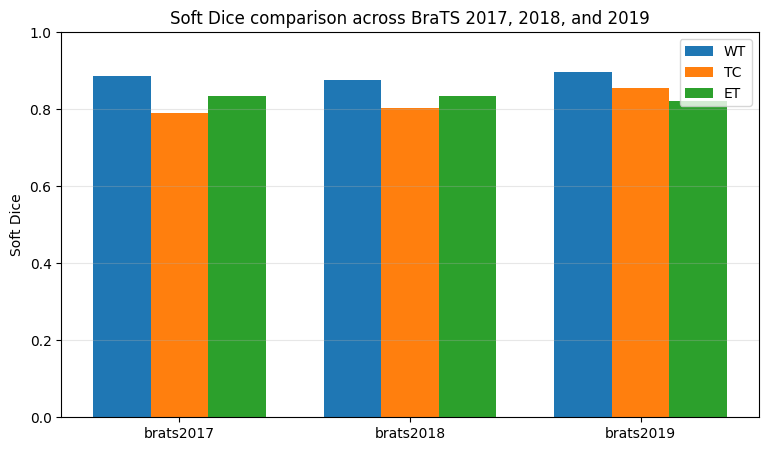

Saved Soft Dice plot to:
/home/zak/brats_project/outputs/soft_dice_comparison_all_datasets.png


In [23]:
# ============================================================
# Plot 2: Soft Dice comparison for WT, TC, ET
# ============================================================

datasets = final_summary_all_datasets["Dataset"]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - width, final_summary_all_datasets["Soft Dice WT"], width, label="WT")
plt.bar(x, final_summary_all_datasets["Soft Dice TC"], width, label="TC")
plt.bar(x + width, final_summary_all_datasets["Soft Dice ET"], width, label="ET")

plt.xticks(x, datasets)
plt.ylabel("Soft Dice")
plt.title("Soft Dice comparison across BraTS 2017, 2018, and 2019")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)

soft_dice_plot_path = OUTPUT_DIR / "soft_dice_comparison_all_datasets.png"
plt.savefig(soft_dice_plot_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved Soft Dice plot to:")
print(soft_dice_plot_path)

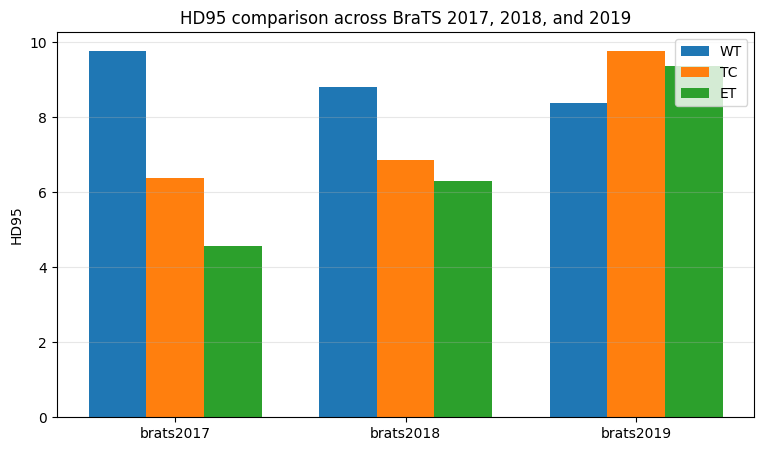

Saved HD95 plot to:
/home/zak/brats_project/outputs/hd95_comparison_all_datasets.png


In [24]:
# ============================================================
# Plot 3: HD95 comparison for WT, TC, ET
# ============================================================

datasets = final_summary_all_datasets["Dataset"]

x = np.arange(len(datasets))
width = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - width, final_summary_all_datasets["HD95 WT"], width, label="WT")
plt.bar(x, final_summary_all_datasets["HD95 TC"], width, label="TC")
plt.bar(x + width, final_summary_all_datasets["HD95 ET"], width, label="ET")

plt.xticks(x, datasets)
plt.ylabel("HD95")
plt.title("HD95 comparison across BraTS 2017, 2018, and 2019")
plt.legend()
plt.grid(axis="y", alpha=0.3)

hd95_plot_path = OUTPUT_DIR / "hd95_comparison_all_datasets.png"
plt.savefig(hd95_plot_path, dpi=200, bbox_inches="tight")

plt.show()

print("Saved HD95 plot to:")
print(hd95_plot_path)

In [25]:
# ============================================================
# Cell 15: Final prediction visualization for all datasets
# Uses preprocessed .npy validation samples
# ============================================================

import matplotlib.pyplot as plt
import gc

def visualize_predictions_one_dataset(dataset_name, num_examples=3):
    print("\n" + "=" * 80)
    print("VISUALIZING PREDICTIONS FOR:", dataset_name)
    print("=" * 80)

    # Correct new checkpoint path
    checkpoint_path = OUTPUT_DIR / f"best_agresunet_{dataset_name}_40epochs_npy_generator.keras"

    print("\nLoading best model from:")
    print(checkpoint_path)

    if not checkpoint_path.exists():
        print("Model checkpoint not found:", checkpoint_path)
        return None

    # Load validation data from preprocessed .npy files
    print("\nReloading validation data from preprocessed .npy files...")

    X_val_full, y_val_full = load_validation_from_processed(
        dataset_name,
        max_eval_slices=1000
    )

    print("X_val_full:", X_val_full.shape)
    print("y_val_full:", y_val_full.shape)

    if len(X_val_full) == 0:
        print("No validation samples loaded.")
        return None

    # Load best model
    best_model = tf.keras.models.load_model(
        checkpoint_path,
        compile=False
    )

    # Predict
    pred_probs = best_model.predict(
        X_val_full,
        batch_size=8,
        verbose=1
    )

    true_masks = np.argmax(y_val_full, axis=-1)
    pred_masks = np.argmax(pred_probs, axis=-1)

    print("\nTrue labels:", np.unique(true_masks))
    print("Predicted labels:", np.unique(pred_masks))

    # Choose validation slices with largest tumor area
    tumor_pixels = np.sum(true_masks > 0, axis=(1, 2))
    example_ids = np.argsort(tumor_pixels)[-num_examples:][::-1]

    print("\nExamples selected:", example_ids)
    print("Tumor pixels in selected examples:", tumor_pixels[example_ids])

    plt.figure(figsize=(16, 10))

    for row, i in enumerate(example_ids):
        flair = X_val_full[i, :, :, 0]
        t1ce = X_val_full[i, :, :, 2]
        true_mask = true_masks[i]
        pred_mask = pred_masks[i]

        plt.subplot(len(example_ids), 5, row * 5 + 1)
        plt.imshow(flair, cmap="gray")
        plt.title("Flair")
        plt.axis("off")

        plt.subplot(len(example_ids), 5, row * 5 + 2)
        plt.imshow(t1ce, cmap="gray")
        plt.title("T1ce")
        plt.axis("off")

        plt.subplot(len(example_ids), 5, row * 5 + 3)
        plt.imshow(true_mask)
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(len(example_ids), 5, row * 5 + 4)
        plt.imshow(pred_mask)
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(len(example_ids), 5, row * 5 + 5)
        plt.imshow(flair, cmap="gray")
        plt.imshow(pred_mask, alpha=0.45)
        plt.title("Prediction overlay")
        plt.axis("off")

    plt.suptitle(f"AGResU-Net {dataset_name} validation predictions", fontsize=16)
    plt.tight_layout()

    visual_path = OUTPUT_DIR / f"final_prediction_visualization_{dataset_name}.png"
    plt.savefig(visual_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("\nSaved visualization to:")
    print(visual_path)

    del X_val_full, y_val_full
    del pred_probs, true_masks, pred_masks
    del best_model
    gc.collect()
    tf.keras.backend.clear_session()

    return visual_path


VISUALIZING PREDICTIONS FOR: brats2017

Loading best model from:
/home/zak/brats_project/outputs/best_agresunet_brats2017_40epochs_npy_generator.keras

Reloading validation data from preprocessed .npy files...
Processed validation patients: 57


 26%|█████████████████████▊                                                             | 15/57 [00:02<00:07,  5.38it/s]


X_val_full: (1000, 128, 128, 4)
y_val_full: (1000, 128, 128, 4)
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

True labels: [0 1 2 3]
Predicted labels: [0 1 2 3]

Examples selected: [904 905 910]
Tumor pixels in selected examples: [4941 4926 4867]


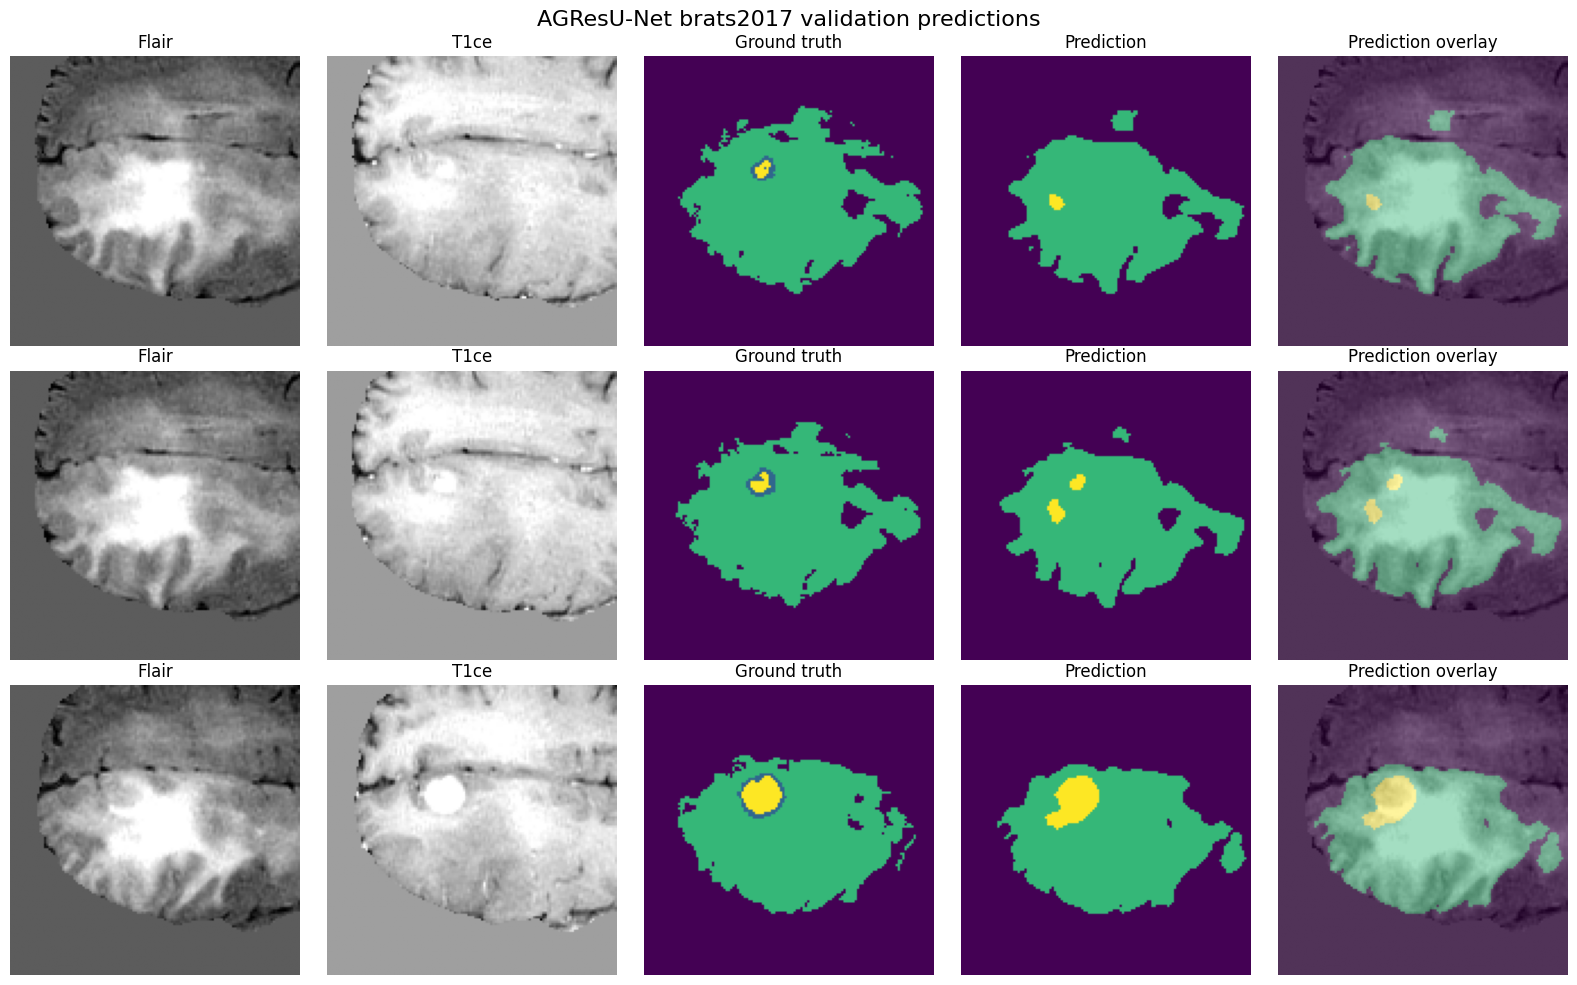


Saved visualization to:
/home/zak/brats_project/outputs/final_prediction_visualization_brats2017.png

VISUALIZING PREDICTIONS FOR: brats2018

Loading best model from:
/home/zak/brats_project/outputs/best_agresunet_brats2018_40epochs_npy_generator.keras

Reloading validation data from preprocessed .npy files...
Processed validation patients: 57


 26%|█████████████████████▊                                                             | 15/57 [00:02<00:07,  5.52it/s]


X_val_full: (1000, 128, 128, 4)
y_val_full: (1000, 128, 128, 4)
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step

True labels: [0 1 2 3]
Predicted labels: [0 1 2 3]

Examples selected: [518 517 520]
Tumor pixels in selected examples: [4423 4410 4408]


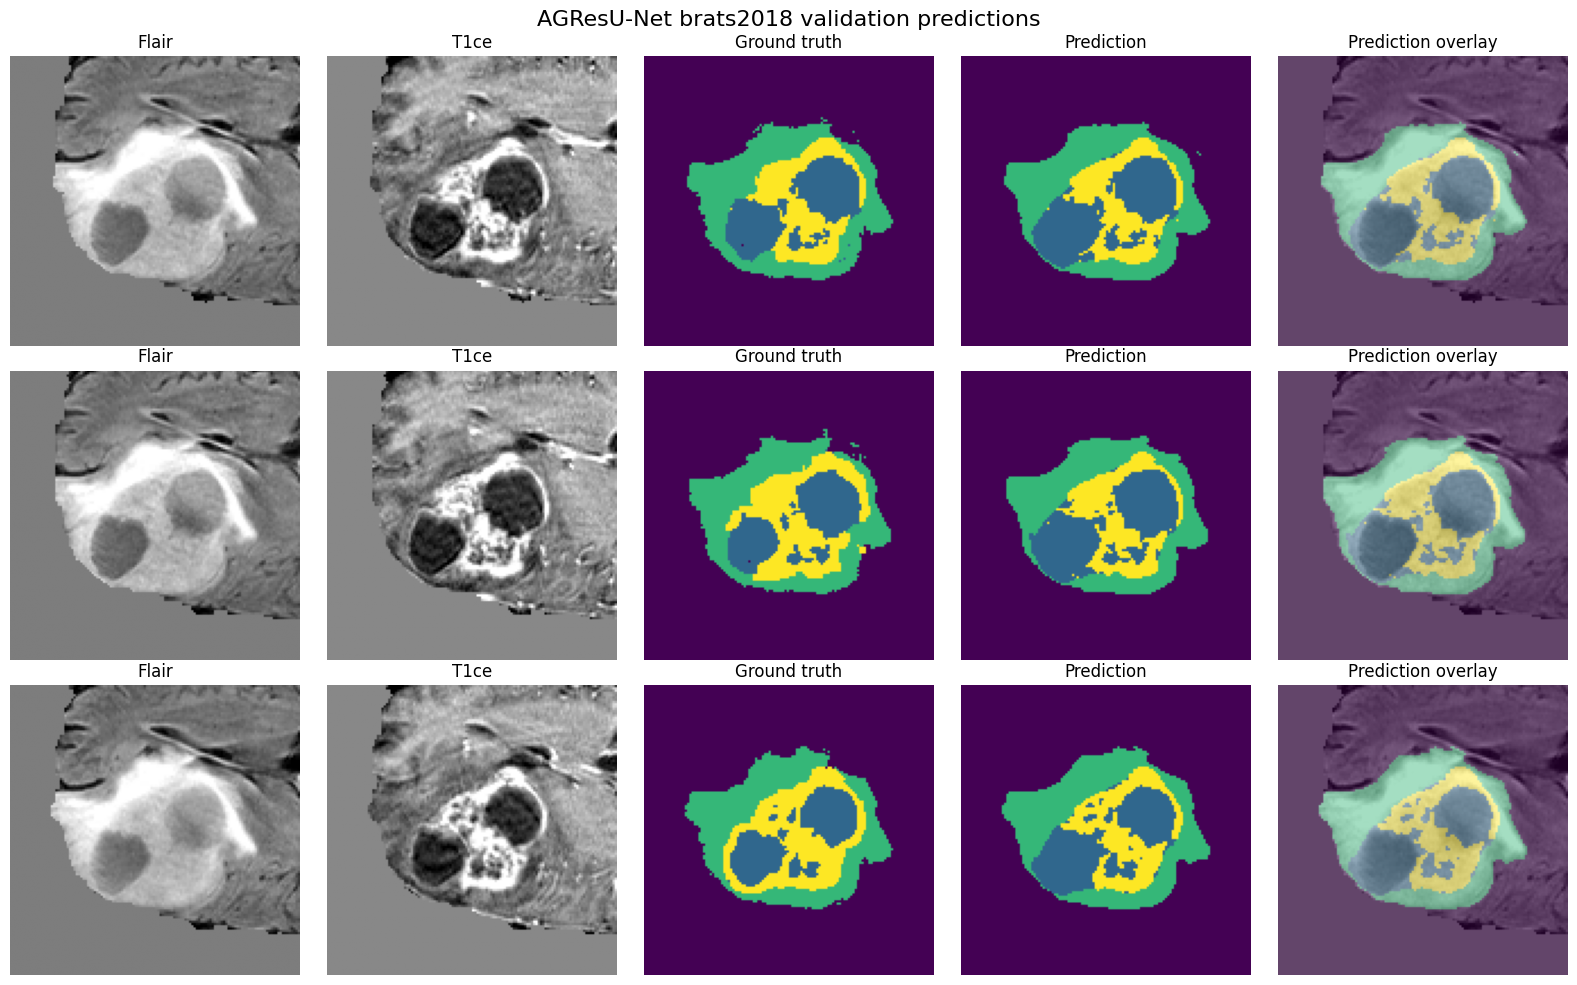


Saved visualization to:
/home/zak/brats_project/outputs/final_prediction_visualization_brats2018.png

VISUALIZING PREDICTIONS FOR: brats2019

Loading best model from:
/home/zak/brats_project/outputs/best_agresunet_brats2019_40epochs_npy_generator.keras

Reloading validation data from preprocessed .npy files...
Processed validation patients: 67


 22%|██████████████████▌                                                                | 15/67 [00:01<00:06,  8.03it/s]


X_val_full: (1000, 128, 128, 4)
y_val_full: (1000, 128, 128, 4)
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step

True labels: [0 1 2 3]
Predicted labels: [0 1 2 3]

Examples selected: [456 451 441]
Tumor pixels in selected examples: [5258 5156 5133]


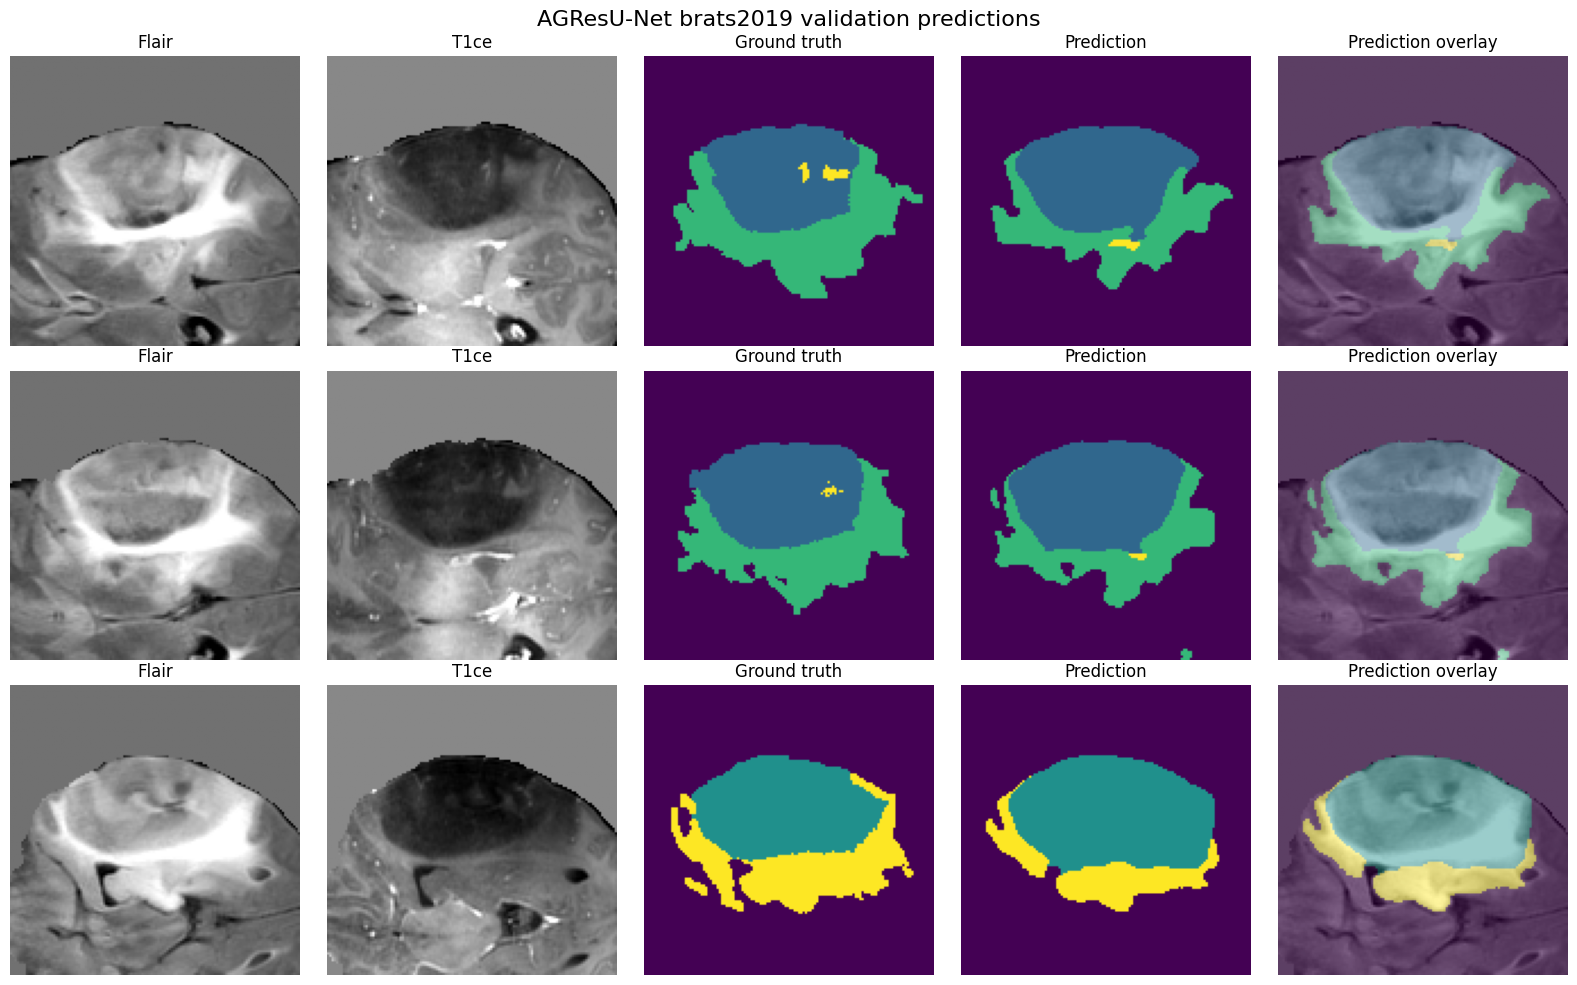


Saved visualization to:
/home/zak/brats_project/outputs/final_prediction_visualization_brats2019.png

All visualizations saved:
brats2017 : /home/zak/brats_project/outputs/final_prediction_visualization_brats2017.png
brats2018 : /home/zak/brats_project/outputs/final_prediction_visualization_brats2018.png
brats2019 : /home/zak/brats_project/outputs/final_prediction_visualization_brats2019.png


In [26]:
# ============================================================
# Cell 16: Run final visualization for BraTS 2017, 2018, 2019
# ============================================================

visual_paths = {}

for dataset_name in ["brats2017", "brats2018", "brats2019"]:
    visual_paths[dataset_name] = visualize_predictions_one_dataset(
        dataset_name,
        num_examples=3
    )

print("\nAll visualizations saved:")

for dataset_name, path in visual_paths.items():
    print(dataset_name, ":", path)